# Visualization Analysis — Product Performance

## Purpose
This notebook visualizes product-level performance across sales, profit, profit margin, discount behavior, and order concentration. The goal is to identify which categories, sub-categories, and products drive revenue, which ones are most profitable, and where commercial performance is weak or concentrated.

## What this notebook covers
- Overall sales vs profit overview
- Sales and profit by category, sub-category, and product
- Profit margin comparisons
- Discount behavior
- Order value concentration and product concentration

## Why this matters
Product-level visuals help connect overall business performance to specific product groups. They make it easier to identify high-revenue but low-margin areas, profitable segments, and concentration risk in the product portfolio.

## Contents
- [1. Setup and styling](#setup-and-styling)
- [2. Executive overview](#executive-overview)
- [3. Category, sub-category, and product performance](#category-sub-category-and-product-performance)
- [4. Discount and pricing effects](#discount-and-pricing-effects)
- [5. Order value and concentration](#order-value-and-concentration)
- [6. Final interpretation](#final-interpretation)

## Setup and styling

In [65]:
# Load required libraries
library(tidyverse)
library(janitor)
library(dplyr)
library(ggplot2)
library(skimr)
library(purrr)
library(lubridate)

# Source helper scripts
source("../../R/apply_factors.R")
source("../../R/analysis_helpers.R")
source("../../R/temporal_helpers.R")

# Load data
tables <- list(
  Orders  = readr::read_csv("../../data/processed/Orders.csv"),
  Returns = readr::read_csv("../../data/processed/Returns.csv"),
  People  = readr::read_csv("../../data/processed/People.csv")
)

# Apply factor transformations
tables <- apply_factors(tables)

# Extract tables
orders  <- tables$Orders
returns <- tables$Returns
people  <- tables$People

Rows: 51290 Columns: 21
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (13): order_id, ship_mode, customer_name, segment, state, country, mark...
dbl   (6): sales, quantity, discount, profit, shipping_cost, year
date  (2): order_date, ship_date

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 1173 Columns: 3
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (2): order_id, market
lgl (1): returned

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 14 Columns: 2
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (2): person, region

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the co

In [66]:
theme_set(
    theme_minimal(base_size = 13) +
        theme(
          plot.title = element_text(size = 18, face = "bold"),
          plot.subtitle = element_text(size = 14),
          axis.title = element_text(size = 16),
          axis.text = element_text(size = 14),
          strip.text = element_text(size = 14, face = "bold"),
          legend.title = element_text(size = 16),
          legend.text = element_text(size = 14),
          panel.grid.minor = element_blank()
    )
)

sales_color <- "#4C78A8"
profit_color <- "#59A14F"
margin_color <- "#E15759"
neutral_color <- "#7F7F7F"

options(
  repr.plot.width = 10,
  repr.plot.height = 5
)

## Executive Overview

### Total Sales vs Total Profit

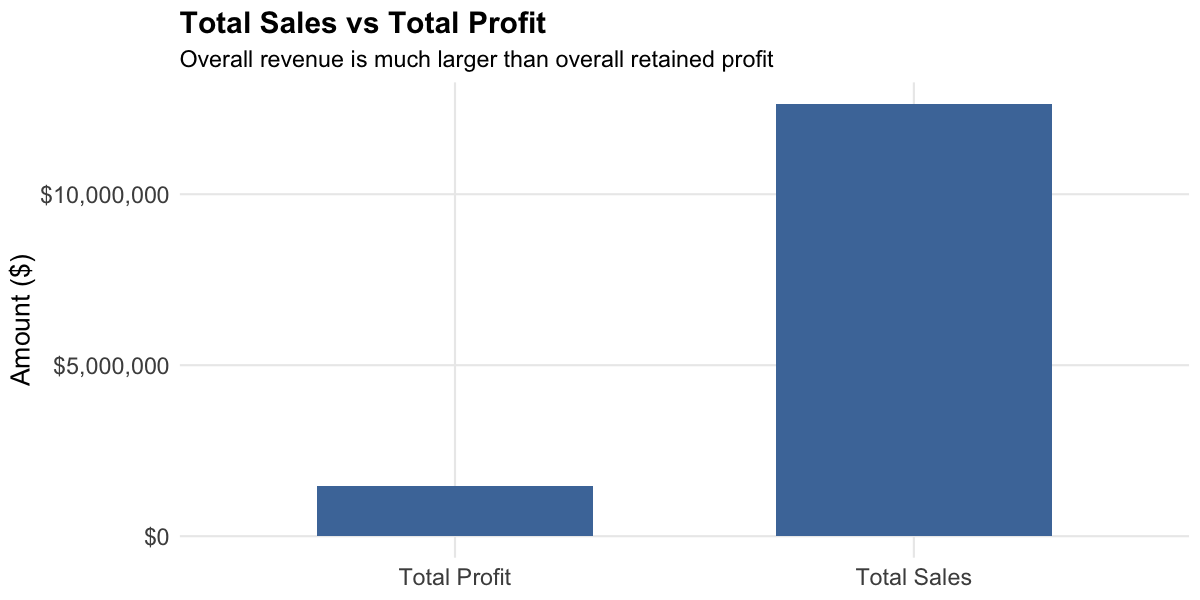

In [67]:
overall_totals <- orders |>
    summarise(
        total_sales = sum(sales),
        total_profit = sum(profit)
    ) |>
    pivot_longer(everything(), names_to = "metric", values_to = "value") |>
    mutate(metric = recode(metric,
                            total_sales = "Total Sales",
                            total_profit = "Total Profit"))

ggplot(overall_totals, aes(x = metric, y = value, fill = metric)) +
    geom_col(width = 0.6, show.legend = FALSE) +
    scale_fill_manual(values = c("Total Sales" = sales_color, "Total Profit" = sales_color)) +
    scale_y_continuous(labels = scales::dollar_format()) +
    labs(
        title = "Total Sales vs Total Profit",
        subtitle = "Overall revenue is much larger than overall retained profit",
        x = NULL,
        y = "Amount ($)"
    )

### Interpretation

The overall comparison shows that total sales are substantially larger than total profit, which is expected, but the gap also highlights that revenue generation and profitability are not the same thing. This makes it important to separate sales-based success from profit-based success in the rest of the notebook. A product group may contribute strongly to revenue while still underperforming on margin.

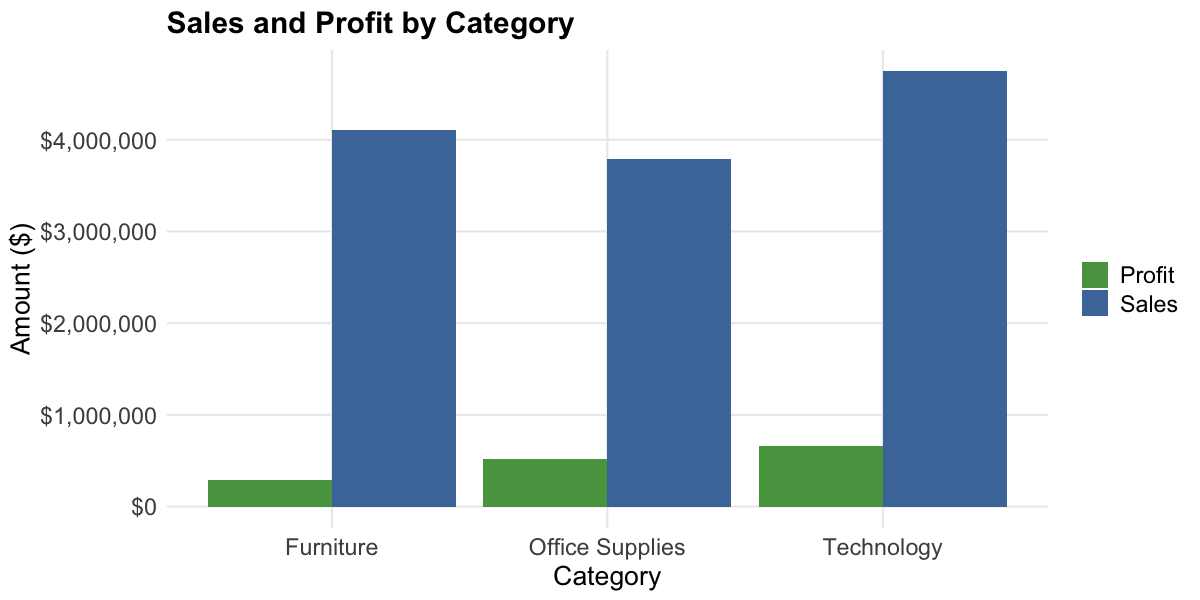

In [68]:
category_perf <- orders |>
    group_by(category) |>
    summarise(
        total_sales = sum(sales),
        total_profit = sum(profit),
        .groups = "drop"
    ) |>
    pivot_longer(
        cols = c(total_sales, total_profit),
        names_to = "metric",
        values_to = "value"
    ) |>
    mutate(metric = recode(metric,
                            total_sales = "Sales",
                            total_profit = "Profit"))

ggplot(category_perf, aes(x = category, y = value, fill = metric)) +
    geom_col(position = "dodge") +
    scale_fill_manual(values = c("Sales" = sales_color, "Profit" = profit_color)) +
    scale_y_continuous(labels = scales::dollar_format()) +
    labs(
        title = "Sales and Profit by Category",
        x = "Category",
        y = "Amount ($)",
        fill = NULL
    )

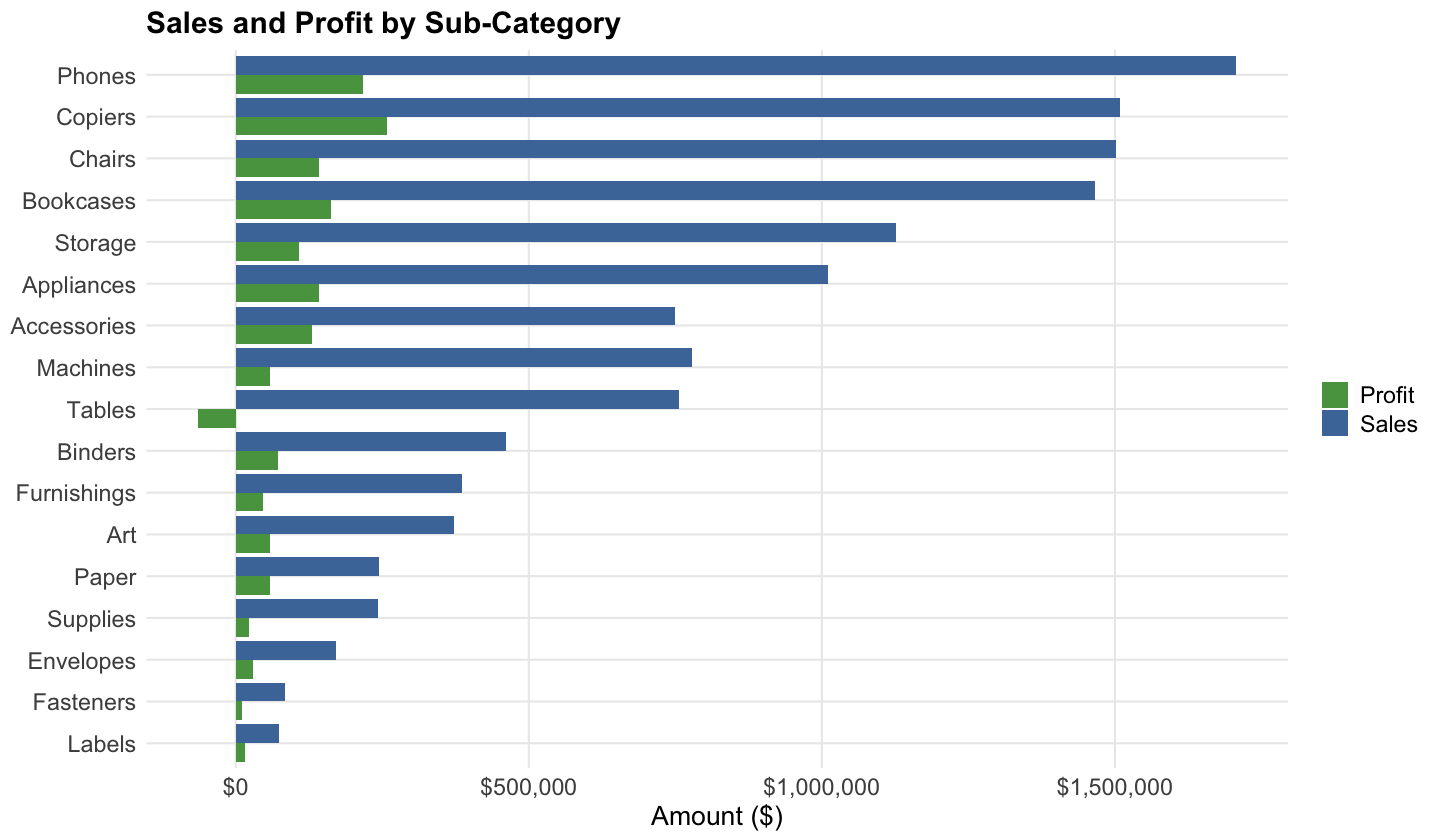

In [69]:
subcategory_perf <- orders |>
    group_by(sub_category) |>
    summarise(
        total_sales = sum(sales),
        total_profit = sum(profit),
        .groups = "drop"
    ) |>
    pivot_longer(
        cols = c(total_sales, total_profit),
        names_to = "metric",
        values_to = "value"
    ) |>
    mutate(metric = recode(metric,
                            total_sales = "Sales",
                            total_profit = "Profit"))

options(repr.plot.width = 12, repr.plot.height = 7)

ggplot(subcategory_perf, aes(x = reorder(sub_category, value), y = value, fill = metric)) +
    geom_col(position = "dodge") +
    coord_flip() +
    scale_fill_manual(values = c("Sales" = sales_color, "Profit" = profit_color)) +
    scale_y_continuous(labels = scales::dollar_format()) +
    labs(
        title = "Sales and Profit by Sub-Category",
        x = NULL,
        y = "Amount ($)",
        fill = NULL
    )

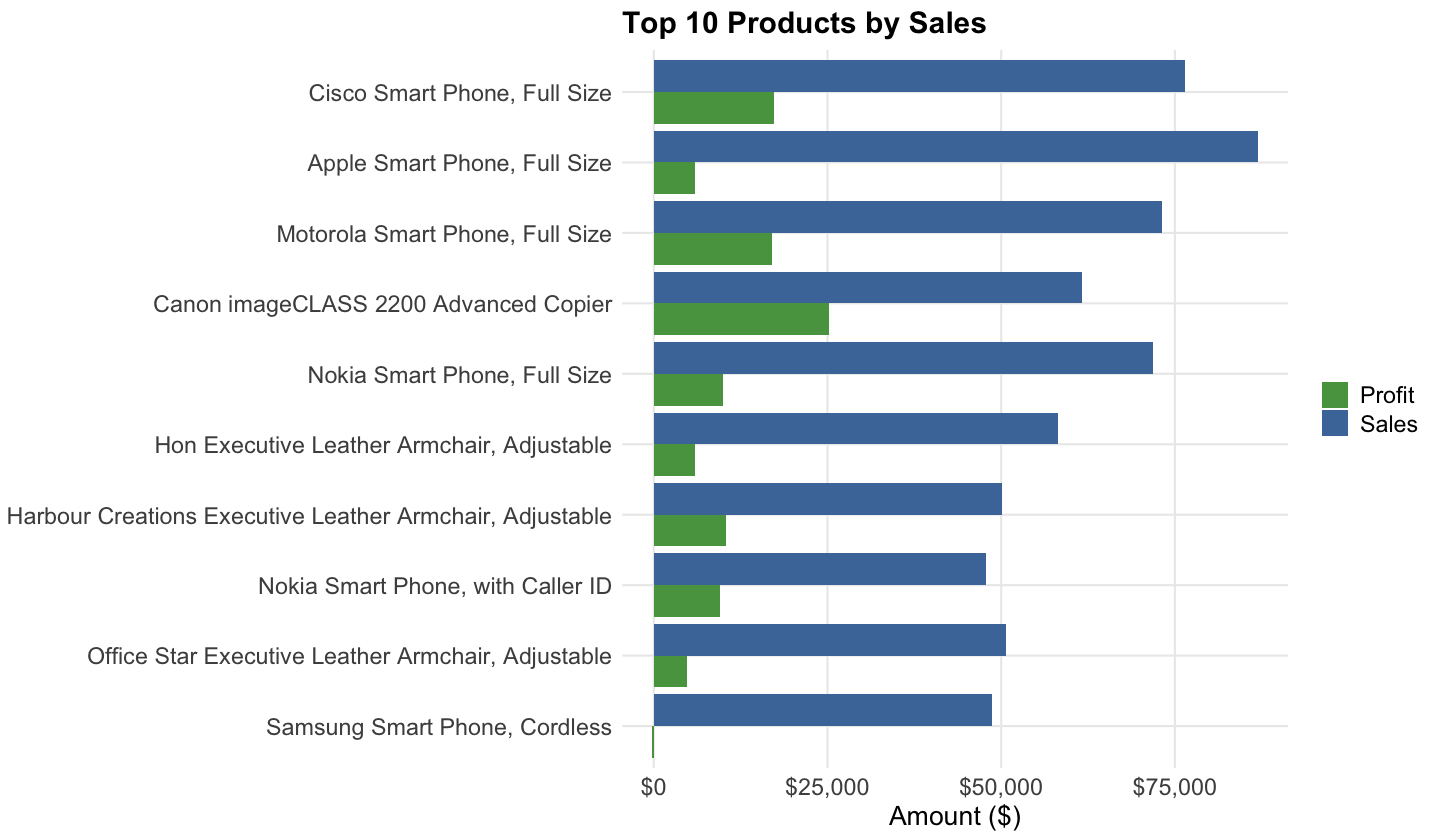

In [70]:
top_products <- orders |>
    group_by(product_name) |>
    summarise(
        total_sales = sum(sales),
        total_profit = sum(profit),
        .groups = "drop"
    ) |>
    slice_max(total_sales, n = 10) |>
    pivot_longer(
        cols = c(total_sales, total_profit),
        names_to = "metric",
        values_to = "value"
    ) |>
    mutate(metric = recode(metric,
                            total_sales = "Sales",
                            total_profit = "Profit"))

options(repr.plot.width = 12, repr.plot.height = 7)

ggplot(top_products, aes(x = reorder(product_name, value), y = value, fill = metric)) +
    geom_col(position = "dodge") +
    coord_flip() +
    scale_fill_manual(values = c("Sales" = sales_color, "Profit" = profit_color)) +
    scale_y_continuous(labels = scales::dollar_format()) +
    labs(
        title = "Top 10 Products by Sales",
        x = NULL,
        y = "Amount ($)",
        fill = NULL
    )

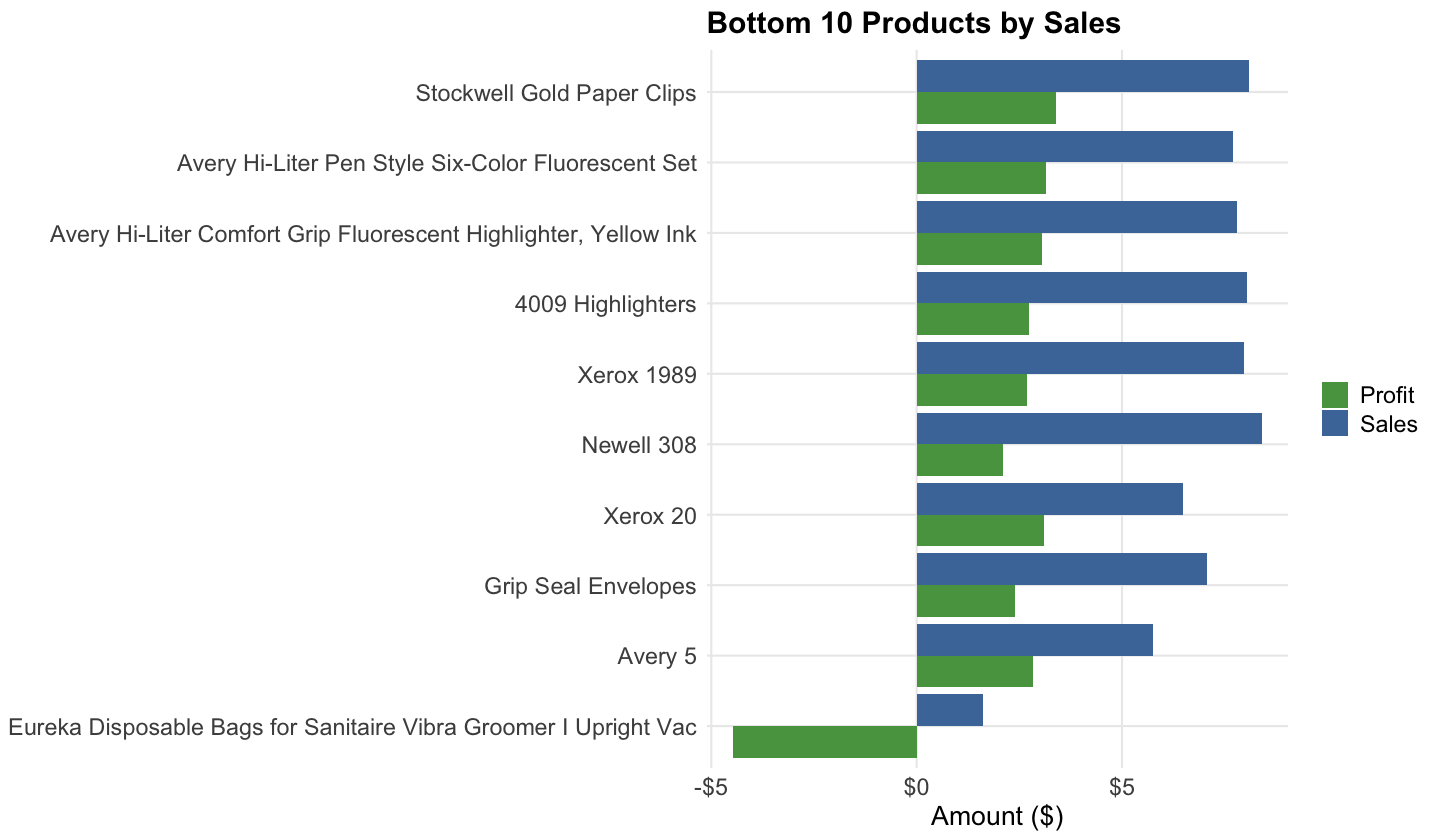

In [71]:
bottom_products <- orders |>
    group_by(product_name) |>
    summarise(
        total_sales = sum(sales),
        total_profit = sum(profit),
        .groups = "drop"
    ) |>
    slice_min(total_sales, n = 10) |>
    pivot_longer(
        cols = c(total_sales, total_profit),
        names_to = "metric",
        values_to = "value"
    ) |>
    mutate(metric = recode(metric,
                            total_sales = "Sales",
                            total_profit = "Profit"))

ggplot(bottom_products, aes(x = reorder(product_name, value), y = value, fill = metric)) +
    geom_col(position = "dodge") +
    coord_flip() +
    scale_fill_manual(values = c("Sales" = sales_color, "Profit" = profit_color)) +
    scale_y_continuous(labels = scales::dollar_format()) +
    labs(
        title = "Bottom 10 Products by Sales",
        x = NULL,
        y = "Amount ($)",
        fill = NULL
    )

### Interpretation

The category, sub-category, and product comparisons show that strong sales contribution does not always translate into equally strong profit contribution. Some product groups appear to be commercially important because of their revenue size, while others contribute less to sales but are more efficient in converting revenue into profit. Looking at top and bottom products separately is especially useful because the extremes reveal both concentration and underperformance more clearly than aggregate summaries alone.

### Profit Margin by Category/Sub-Category/Product

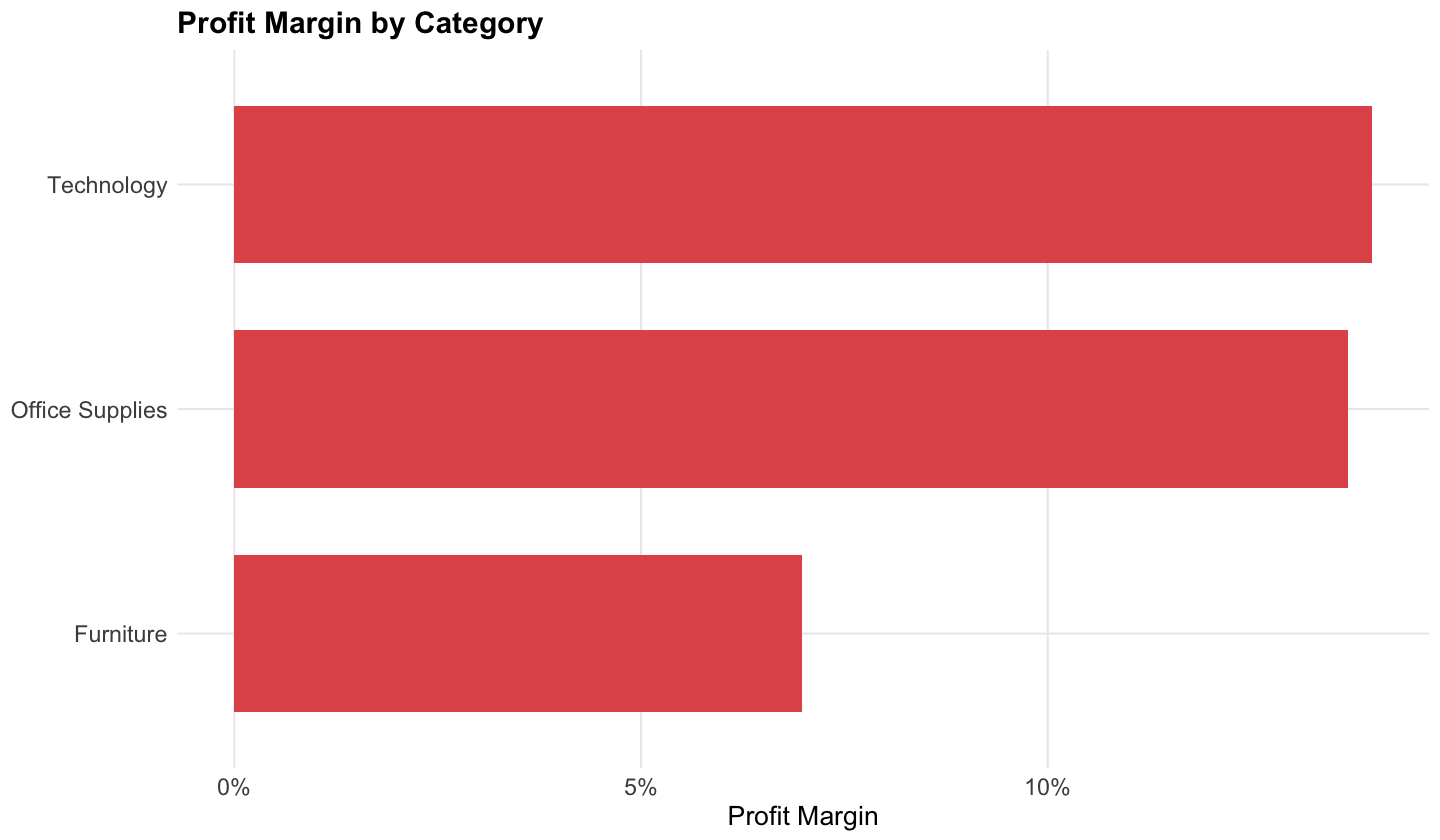

In [72]:
category_margin <- orders |>
    group_by(category) |>
    summarise(
        total_sales = sum(sales),
        total_profit = sum(profit),
        profit_margin = total_profit / total_sales,
        .groups = "drop"
    )

ggplot(category_margin, aes(x = reorder(category, profit_margin), y = profit_margin)) +
    geom_col(fill = margin_color, width = 0.7) +
    coord_flip() +
    scale_y_continuous(labels = scales::percent_format(accuracy = 1)) +
    labs(
        title = "Profit Margin by Category",
        x = NULL,
        y = "Profit Margin"
    )

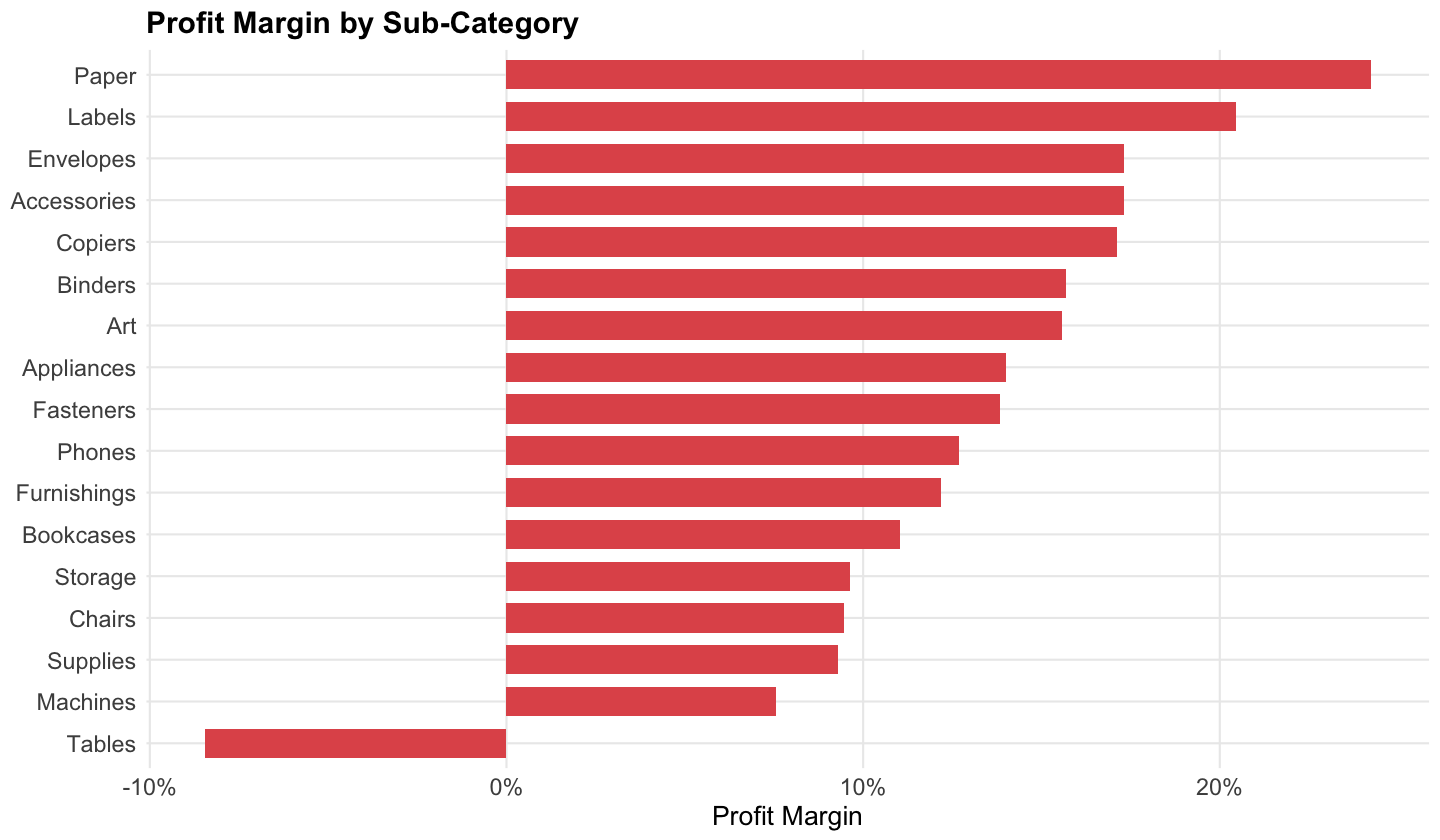

In [73]:
subcategory_margin <- orders |>
    group_by(sub_category) |>
    summarise(
        total_sales = sum(sales),
        total_profit = sum(profit),
        profit_margin = total_profit / total_sales,
        .groups = "drop"
    )

ggplot(subcategory_margin, aes(x = reorder(sub_category, profit_margin), y = profit_margin)) +
    geom_col(fill = margin_color, width = 0.7) +
    scale_y_continuous(labels = scales::percent_format(accuracy = 1)) +
    coord_flip() +
    labs(
        title = "Profit Margin by Sub-Category",
        x = NULL,
        y = "Profit Margin"
    ) 

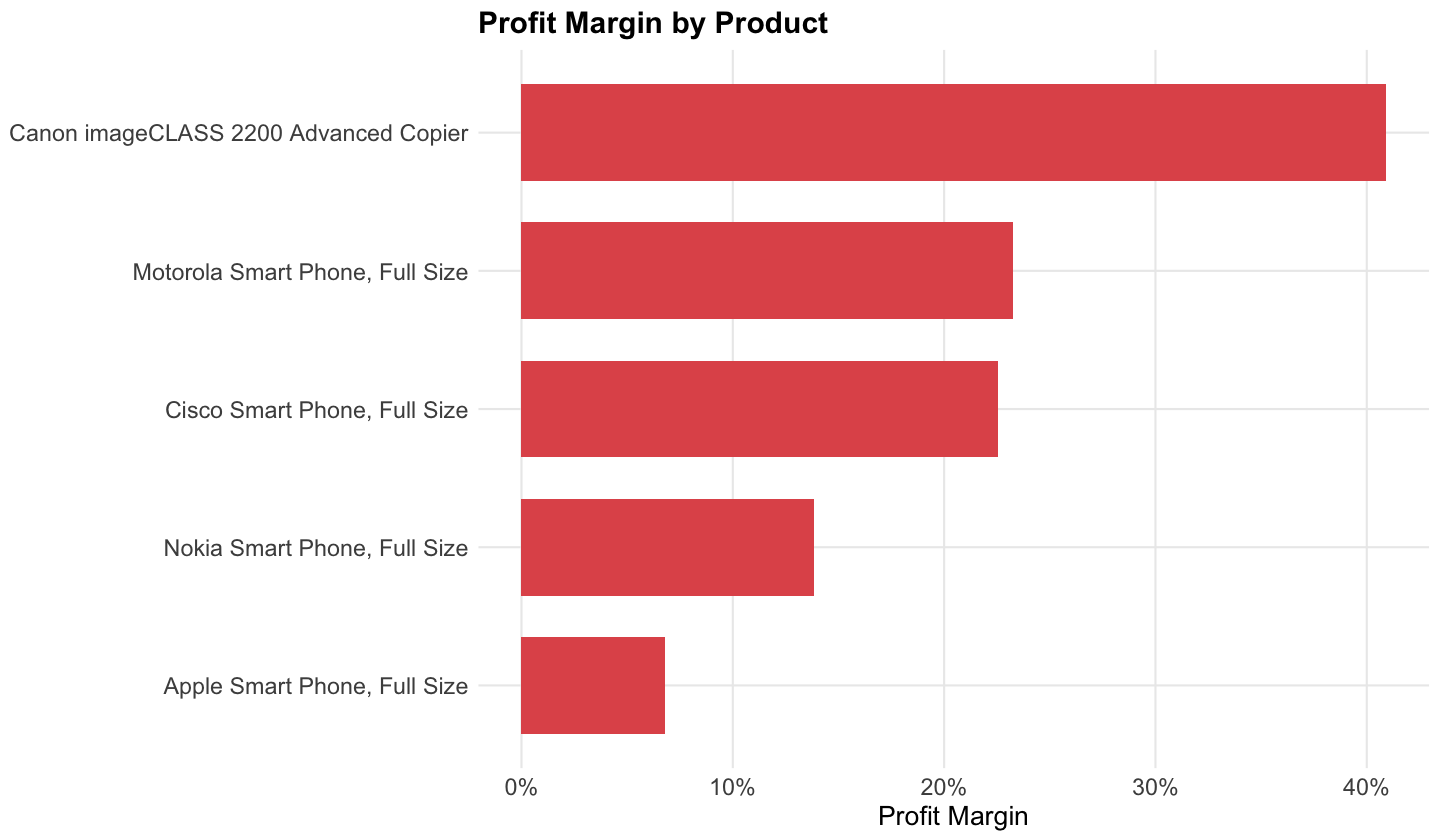

In [74]:
product_margin <- orders |>
    group_by(product_name) |>
    summarise(
        total_sales = sum(sales),
        total_profit = sum(profit),
        profit_margin = total_profit / total_sales,
        .groups = "drop"
    ) |>
    slice_max(total_sales, n = 5)

ggplot(product_margin, aes(x = reorder(product_name, profit_margin), y = profit_margin)) +
    geom_col(fill = margin_color, width = 0.7) +
    scale_y_continuous(labels = scales::percent_format(accuracy = 1)) +
    coord_flip() +
    labs(
        title = "Profit Margin by Product",
        x = NULL,
        y = "Profit Margin"
    )

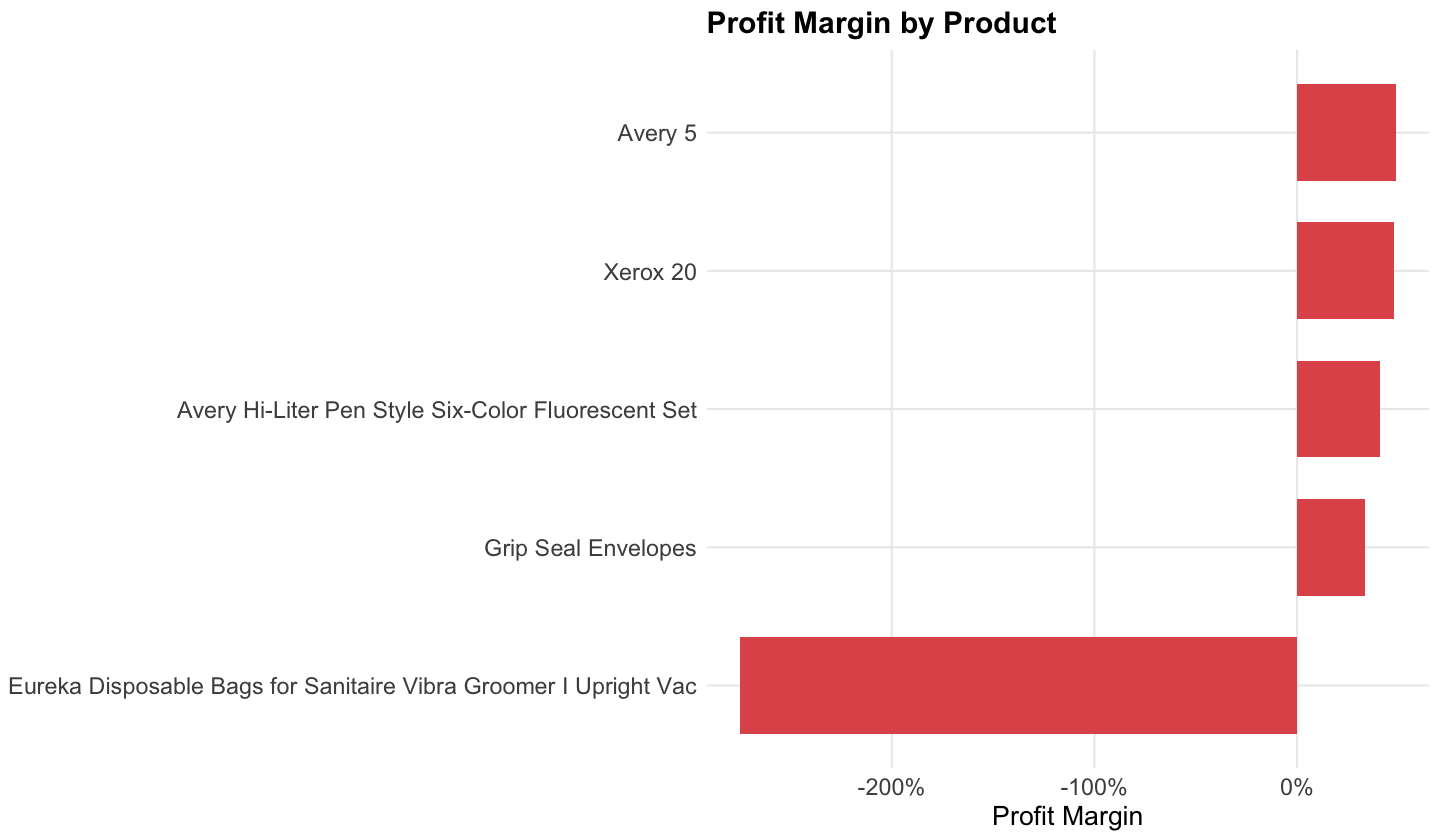

In [75]:
product_margin <- orders |>
    group_by(product_name) |>
    summarise(
        total_sales = sum(sales),
        total_profit = sum(profit),
        profit_margin = total_profit / total_sales,
        .groups = "drop"
    ) |>
    slice_min(total_sales, n = 5)

ggplot(product_margin, aes(x = reorder(product_name, profit_margin), y = profit_margin)) +
    geom_col(fill = margin_color, width = 0.7) +
    scale_y_continuous(labels = scales::percent_format(accuracy = 1)) +
    coord_flip() +
    labs(
        title = "Profit Margin by Product",
        x = NULL,
        y = "Profit Margin"
    ) 

### Interpretation

Profit margin adds an efficiency perspective that raw sales and raw profit alone cannot provide. A category or product may appear important in revenue terms but still generate weak margin, which makes it less attractive strategically. The margin charts therefore help distinguish between scale and quality of performance, and they are especially useful for identifying where commercial success may be driven by volume rather than profitability.

### Sales vs Profit scatter

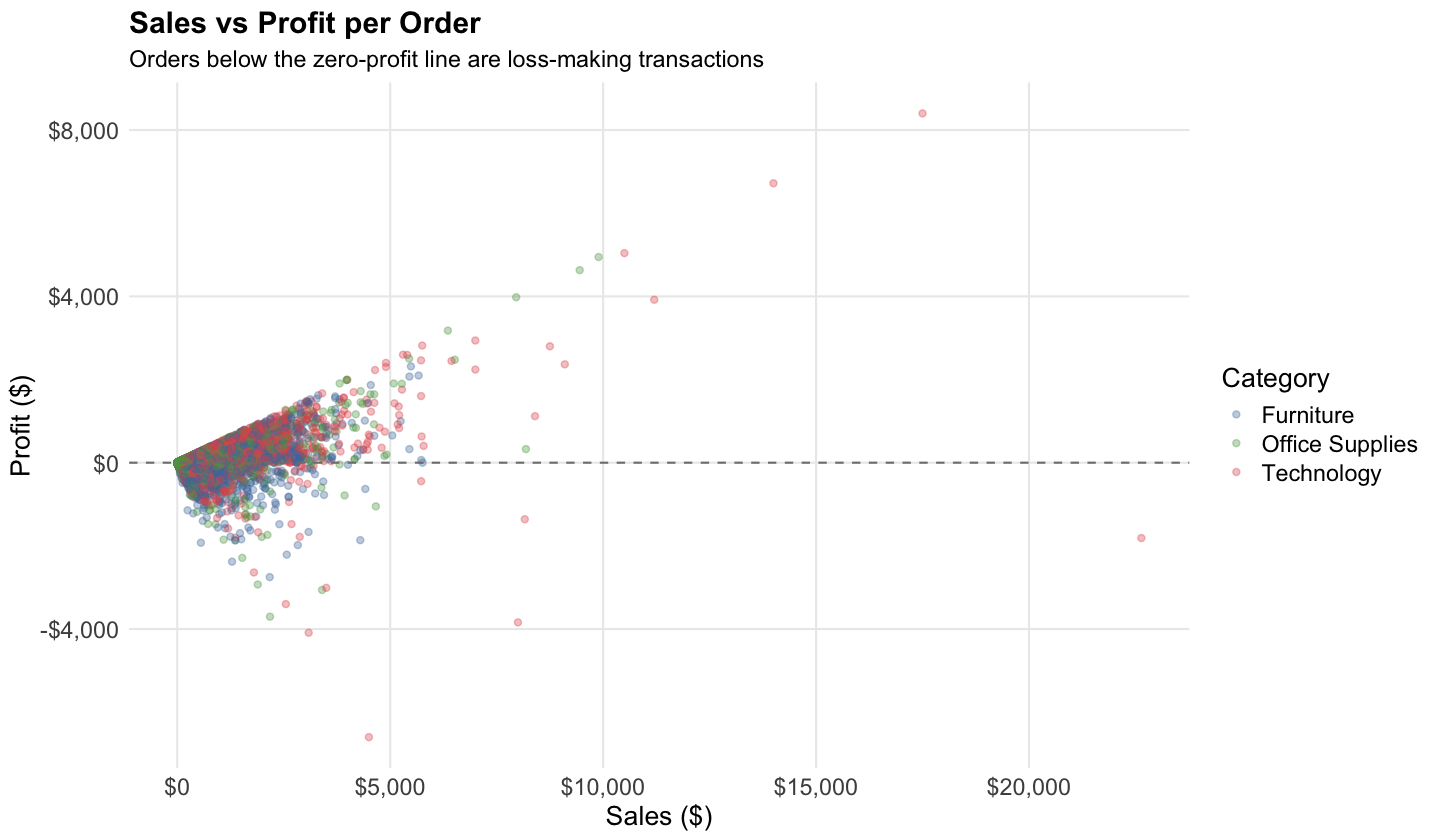

In [76]:
ggplot(orders, aes(x = sales, y = profit, color = category)) +
    geom_point(alpha = 0.35, size = 1.6) +
    geom_hline(yintercept = 0, linetype = "dashed", color = neutral_color) +
    scale_x_continuous(labels = scales::dollar_format()) +
    scale_y_continuous(labels = scales::dollar_format()) +
    scale_color_manual(values = c(
        "Furniture" = sales_color,
        "Office Supplies" = profit_color,
        "Technology" = margin_color
    )) +
    labs(
        title = "Sales vs Profit per Order",
        subtitle = "Orders below the zero-profit line are loss-making transactions",
        x = "Sales ($)",
        y = "Profit ($)",
        color = "Category"
    )

### Interpretation

The sales-versus-profit scatter shows that higher sales do not automatically imply higher profit. While many larger orders are profitable, there are also transactions with meaningful sales values that still fall below the zero-profit line. This suggests that product mix, discounting, or cost structure can make some orders commercially weak even when revenue is relatively high.

# Category, sub-category, and product performance

### Category share of total sales

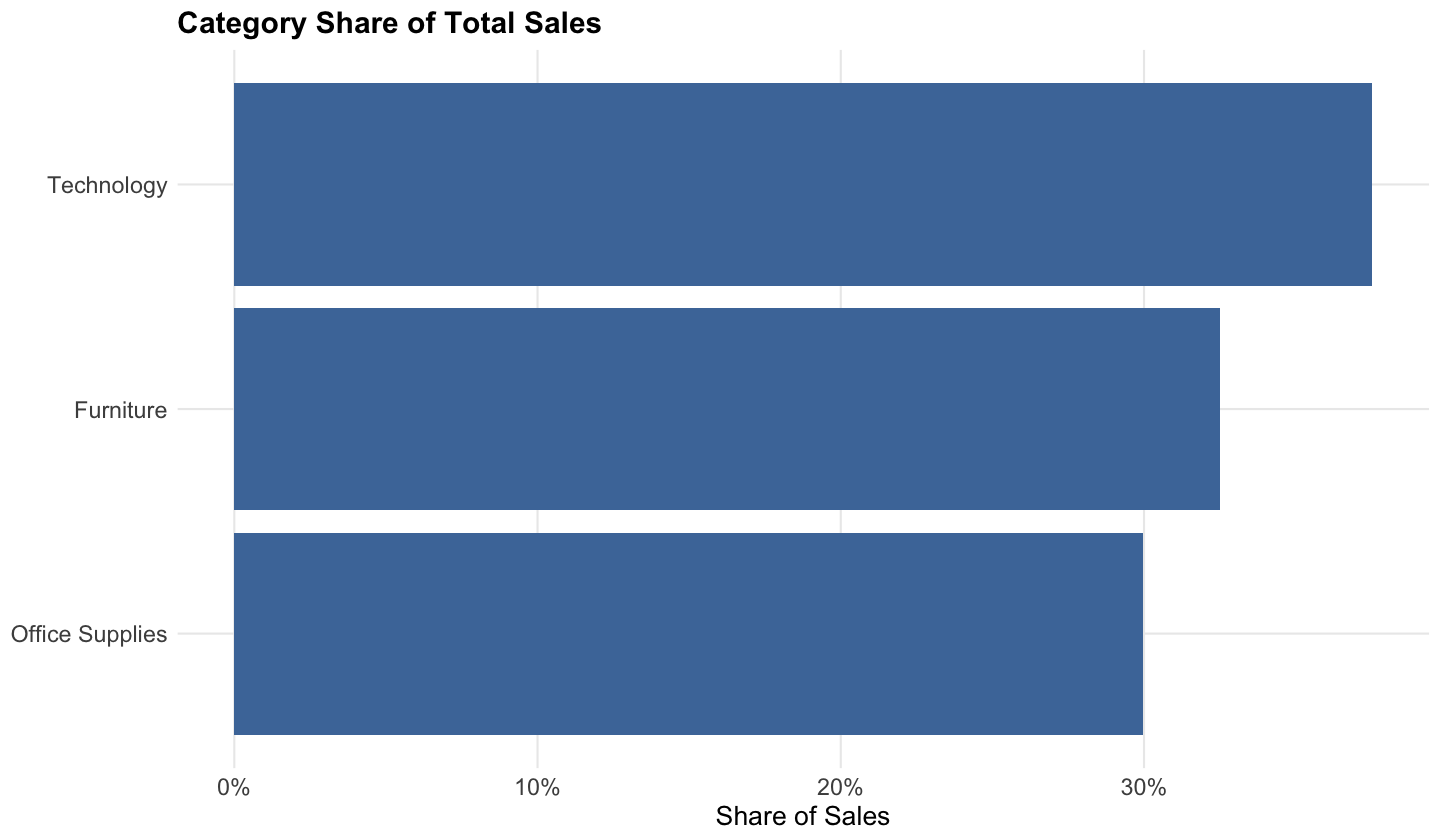

In [77]:
category_sales_share <- orders |>
    group_by(category) |>
    summarise(
        total_sales = sum(sales),
        .groups = "drop"
    ) |>
    mutate(share = total_sales / sum(total_sales))

ggplot(
    category_sales_share,
    aes(x = reorder(category, share), y = share)
) +
    geom_col(fill = sales_color) +
    coord_flip() +
    scale_y_continuous(labels = scales::percent_format()) +
    labs(
        title = "Category Share of Total Sales",
        x = NULL,
        y = "Share of Sales"
    )

### Category share of total profit

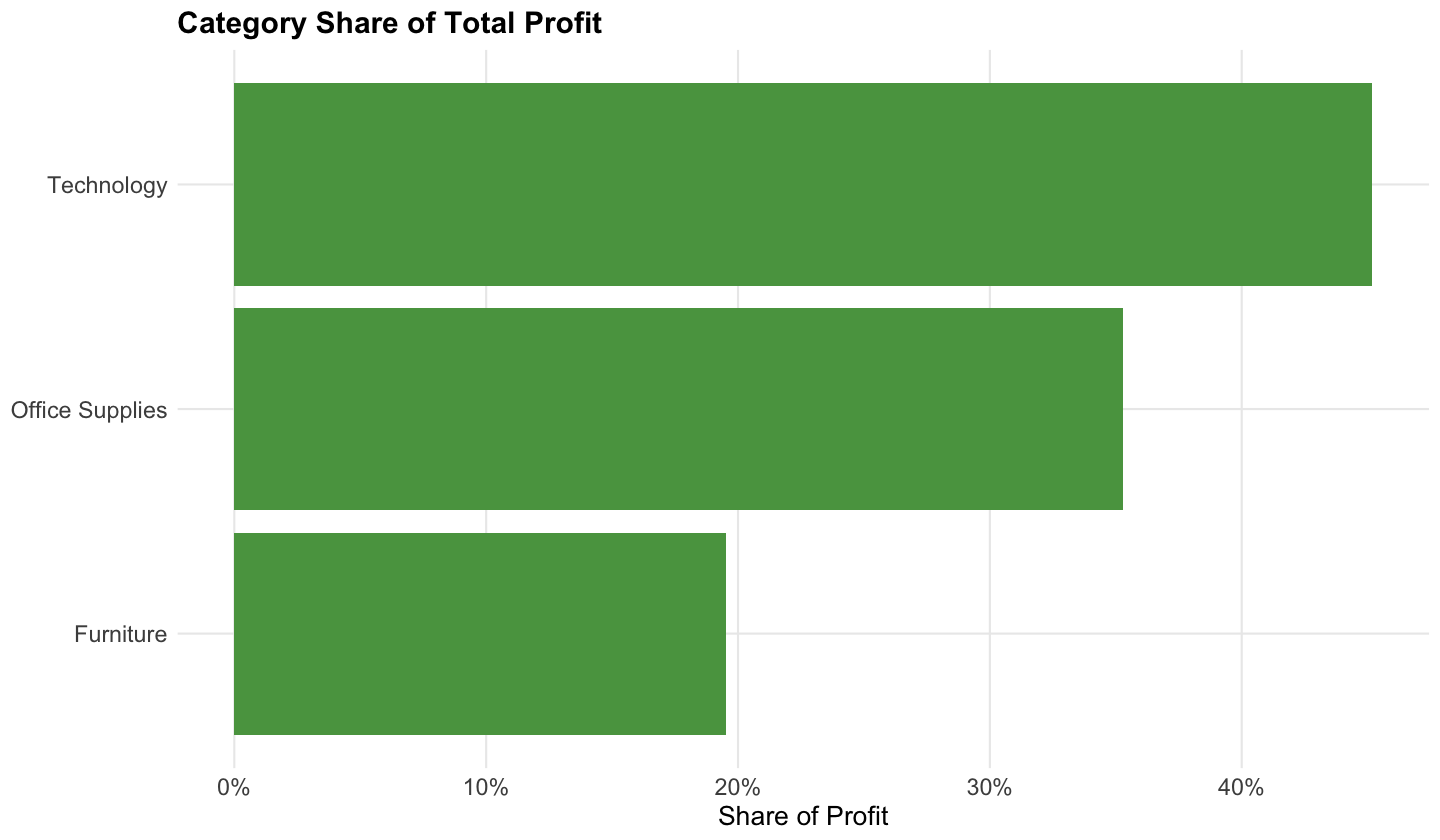

In [78]:
category_profit_share <- orders |> 
    group_by(category) |> 
    summarise(
        total_profit = sum(profit),
        .groups = "drop"
    ) |> 
    mutate(share = total_profit / sum(total_profit))

ggplot(
    category_profit_share,
    aes(x = reorder(category, share), y = share)
) +
    geom_col(fill = profit_color) +
    coord_flip() +
    scale_y_continuous(labels = scales::percent_format()) +
    labs(
        title = "Category Share of Total Profit",
        x = NULL,
        y = "Share of Profit"
    ) 

### Profit margin by category

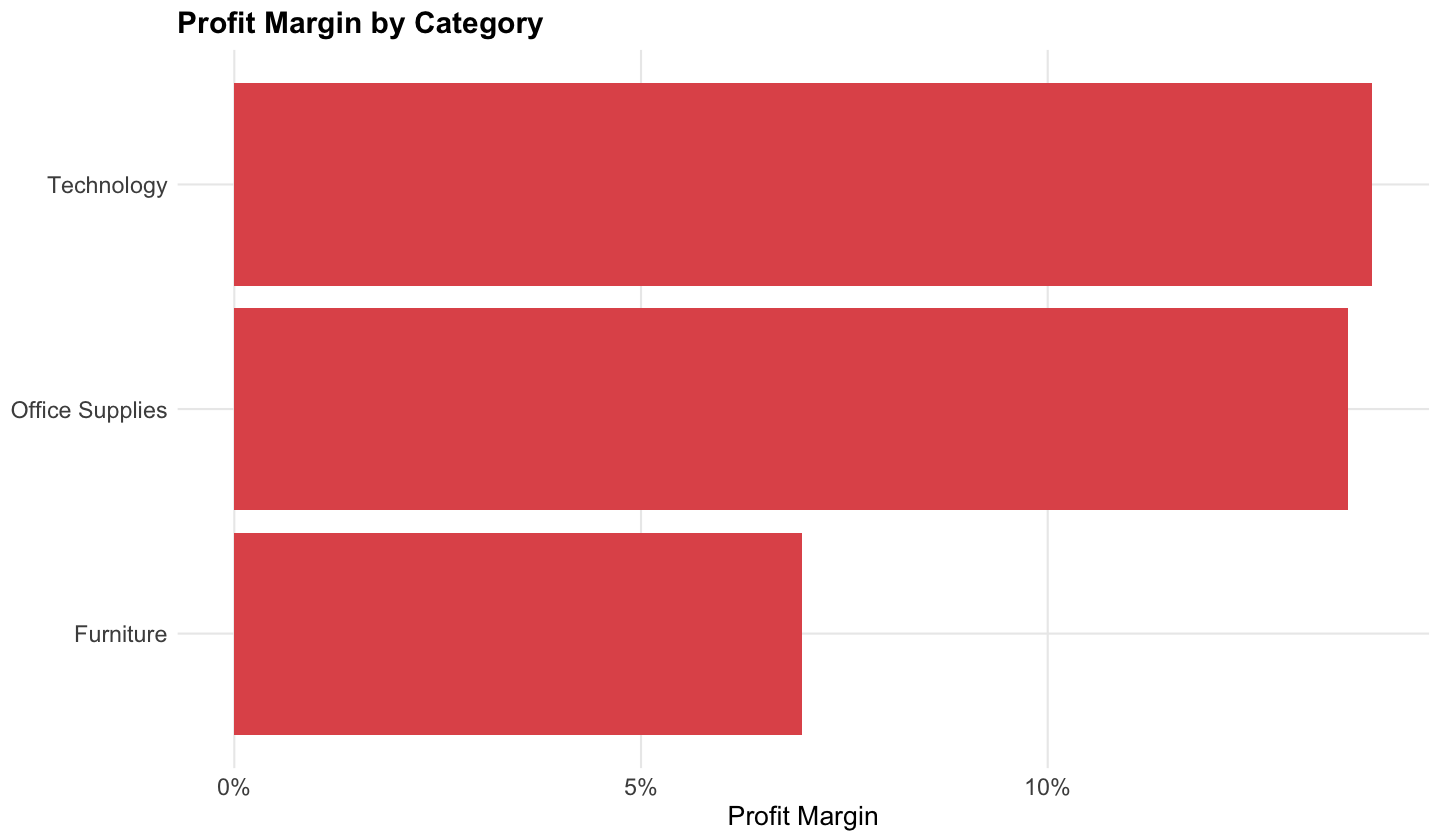

In [79]:
category_margin <- orders |> 
    group_by(category) |> 
    summarise(
        sales = sum(sales),
        profit = sum(profit),
        margin = profit / sales,
        .groups = "drop"
    )

ggplot(
    category_margin,
    aes(x = reorder(category, margin), y = margin)
) +
    geom_col(fill = margin_color) +
    coord_flip() +
    scale_y_continuous(labels = scales::percent_format()) +
    labs(
        title = "Profit Margin by Category",
        x = NULL,
        y = "Profit Margin"
    ) 

### Sub-Category share of total sales

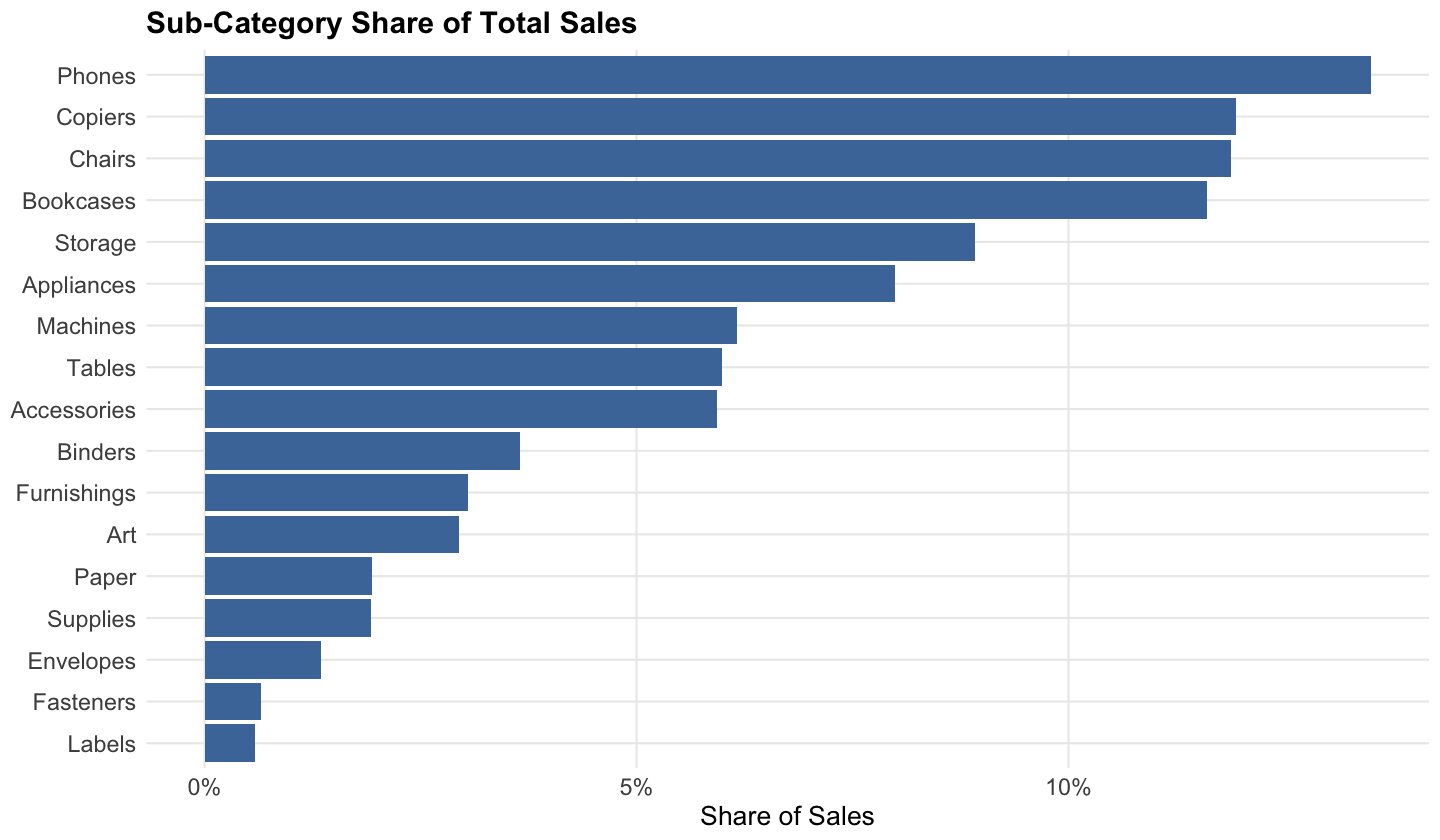

In [80]:
subcategory_sales_share <- orders |> 
    group_by(sub_category) |> 
    summarise(
        total_sales = sum(sales),
        .groups = "drop"
    ) |> 
    mutate(share = total_sales / sum(total_sales))

ggplot(
    subcategory_sales_share,
    aes(x = reorder(sub_category, share), y = share)
) +
    geom_col(fill = sales_color) +
    coord_flip() +
    scale_y_continuous(labels = scales::percent_format()) +
    labs(
        title = "Sub-Category Share of Total Sales",
        x = NULL,
        y = "Share of Sales"
    ) 

### Sub-Category share of total profit

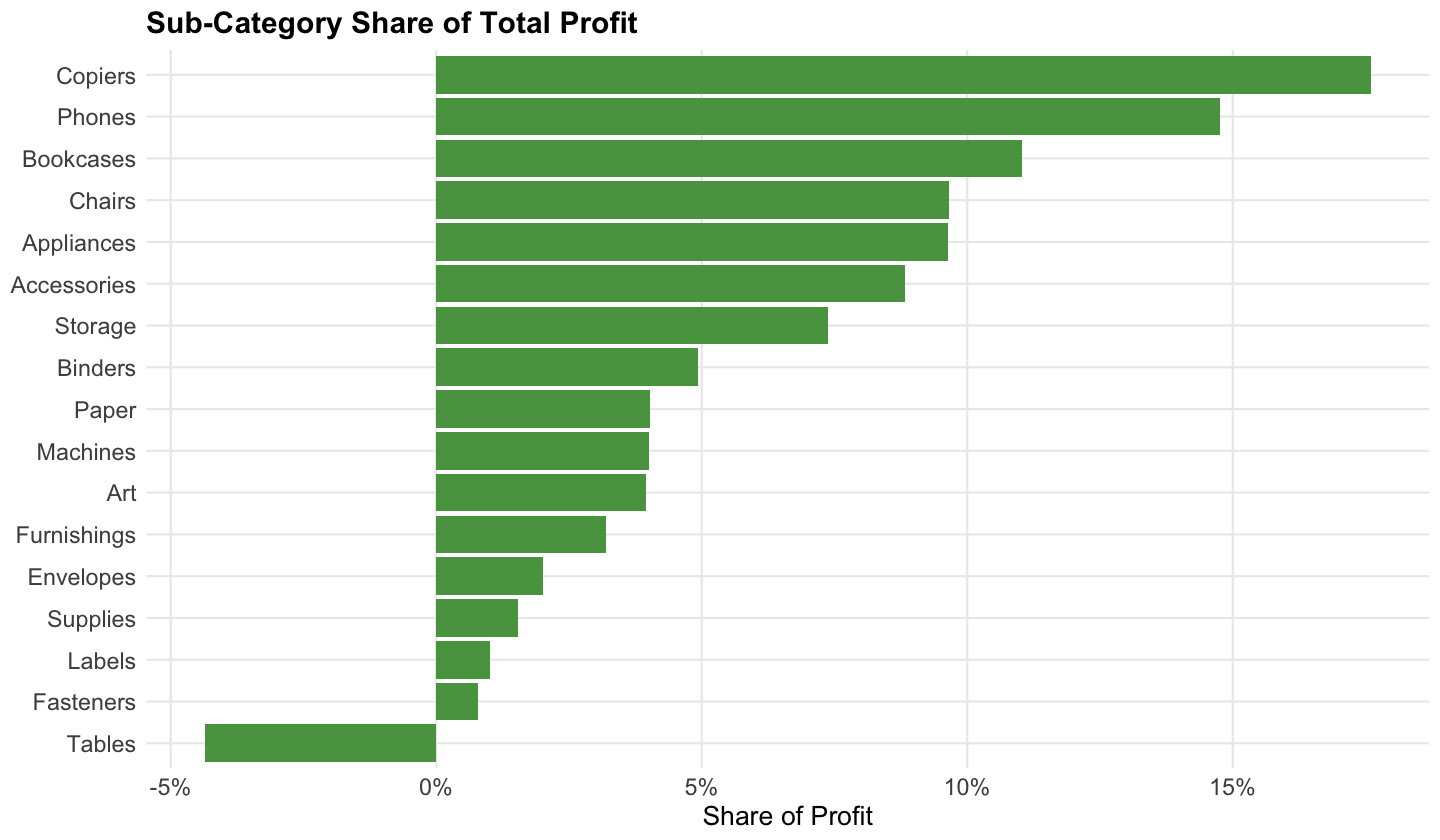

In [81]:
subcategory_profit_share <- orders |> 
    group_by(sub_category) |> 
    summarise(
        total_profit = sum(profit),
        .groups = "drop"
    ) |> 
    mutate(share = total_profit / sum(total_profit))

ggplot(
    subcategory_profit_share,
    aes(x = reorder(sub_category, share), y = share)
) +
    geom_col(fill = profit_color) +
    coord_flip() +
    scale_y_continuous(labels = scales::percent_format()) +
    labs(
        title = "Sub-Category Share of Total Profit",
        x = NULL,
        y = "Share of Profit"
    )

### Profit margin by sub-category

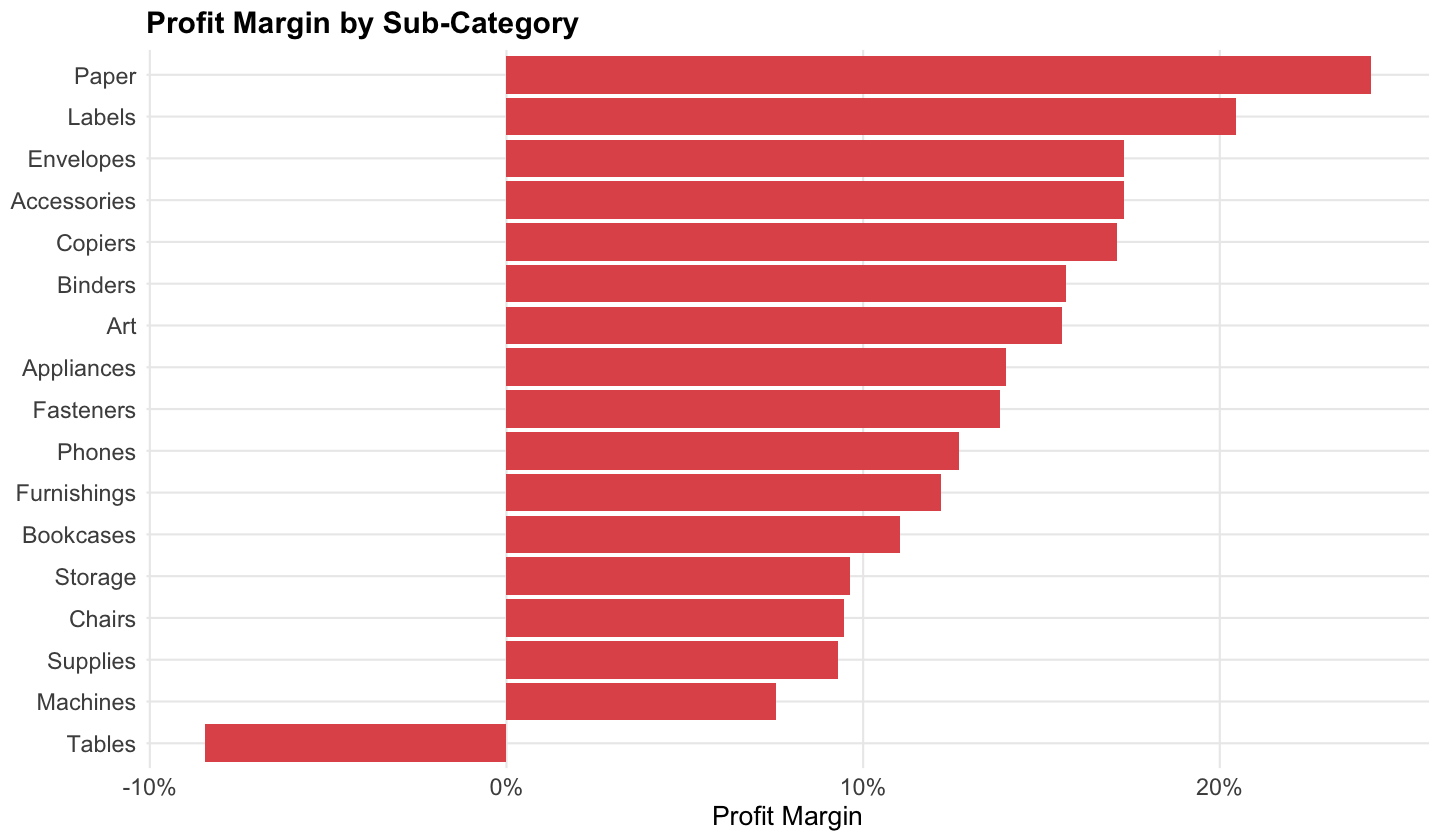

In [82]:
subcategory_margin <- orders |> 
    group_by(sub_category) |> 
    summarise(
        sales = sum(sales),
        profit = sum(profit),
        margin = profit / sales,
        .groups = "drop"
    )

ggplot(
    subcategory_margin,
    aes(x = reorder(sub_category, margin), y = margin)
) +
    geom_col(fill = margin_color) +
    coord_flip() +
    scale_y_continuous(labels = scales::percent_format()) +
    labs(
        title = "Profit Margin by Sub-Category",
        x = NULL,
        y = "Profit Margin"
    ) 

### Product share of total sales

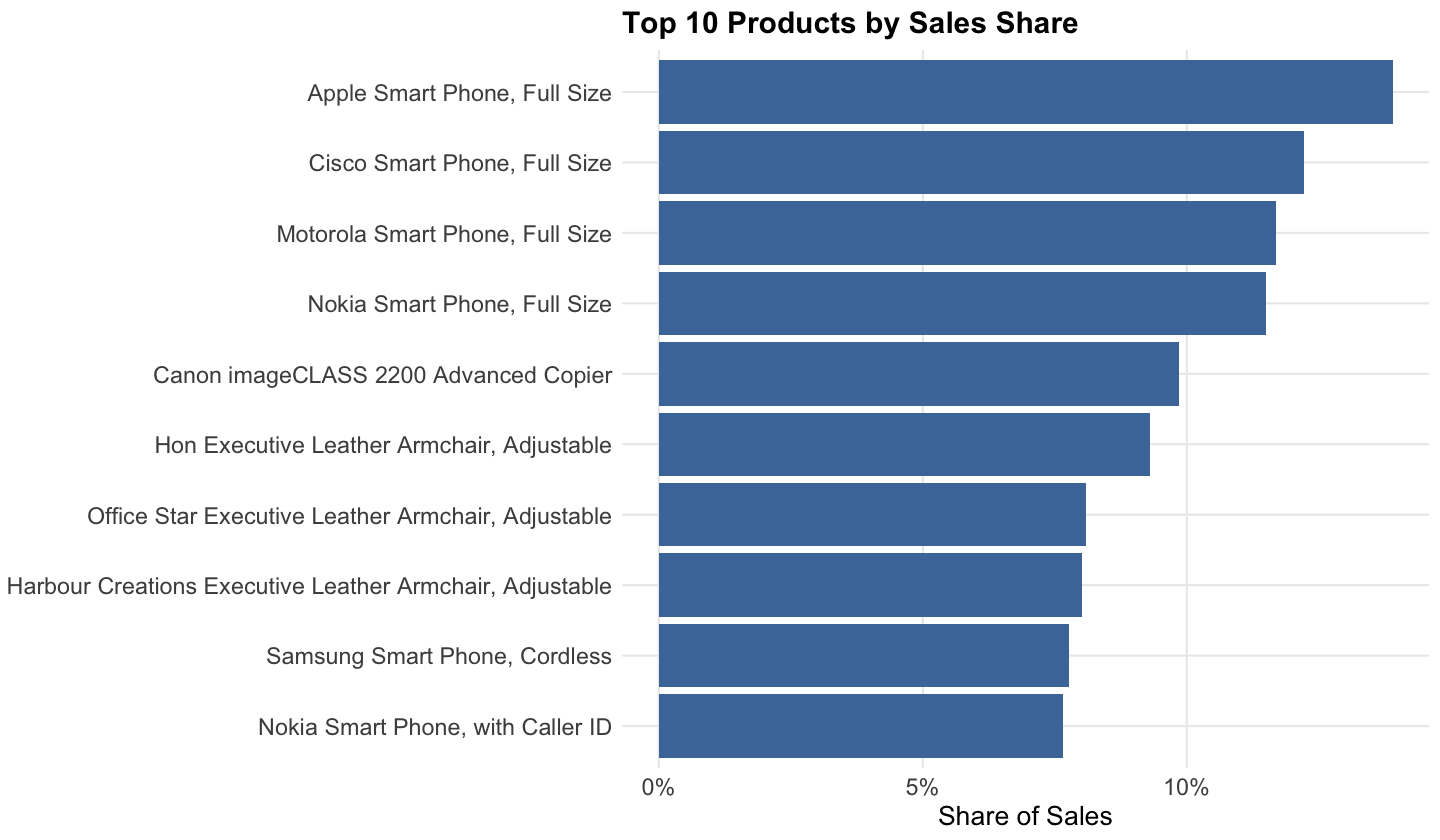

In [83]:
product_sales_share <- orders |> 
    group_by(product_name) |> 
    summarise(
        total_sales = sum(sales),
        .groups = "drop"
    ) |> 
    slice_max(total_sales, n = 10) |> 
    mutate(share = total_sales / sum(total_sales))

ggplot(
    product_sales_share,
    aes(x = reorder(product_name, share), y = share)
) +
    geom_col(fill = sales_color) +
    coord_flip() +
    scale_y_continuous(labels = scales::percent_format()) +
    labs(
        title = "Top 10 Products by Sales Share",
        x = NULL,
        y = "Share of Sales"
    ) 

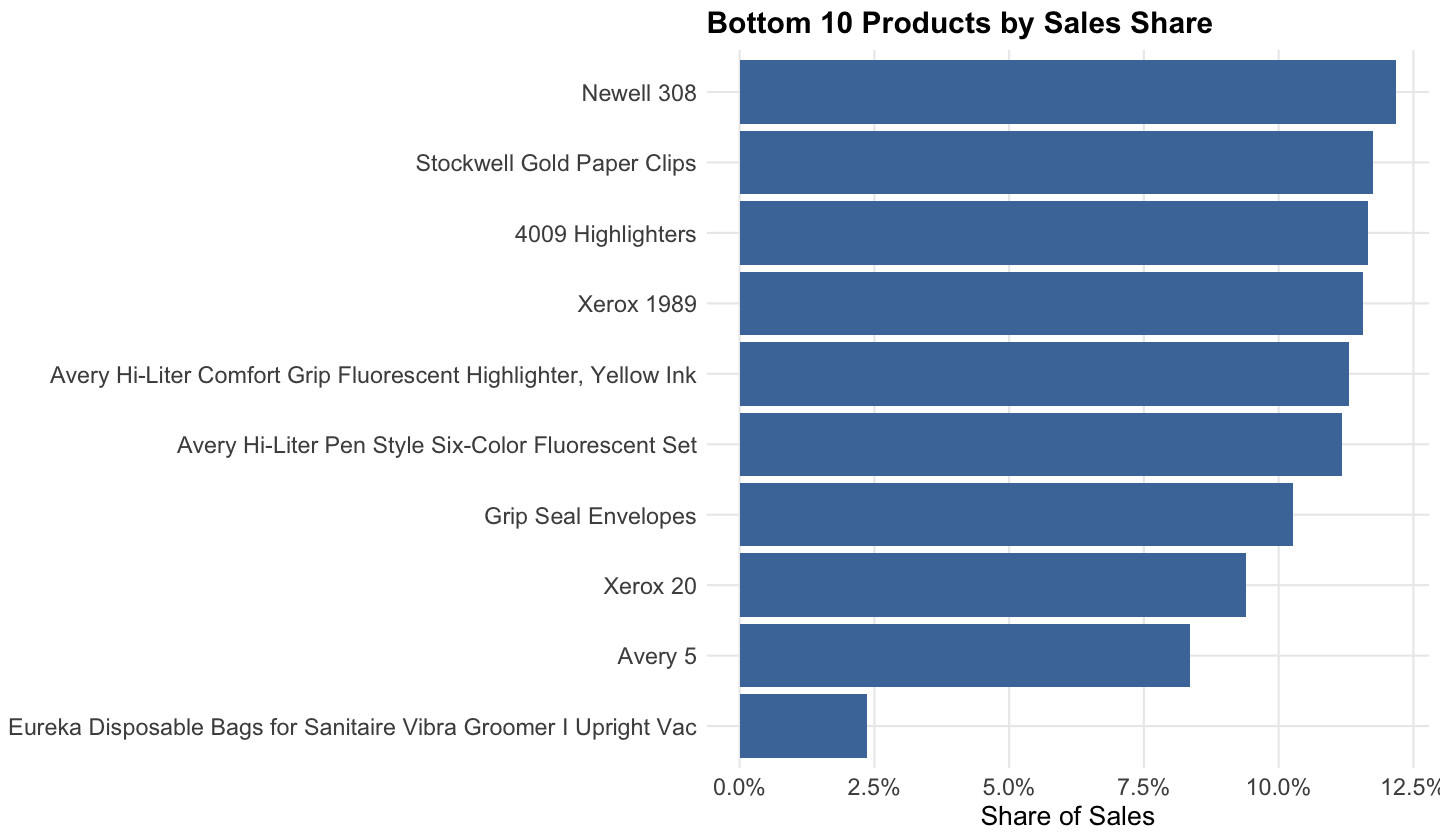

In [84]:
product_sales_share <- orders |> 
    group_by(product_name) |> 
    summarise(
        total_sales = sum(sales),
        .groups = "drop"
    ) |> 
    slice_min(total_sales, n = 10) |> 
    mutate(share = total_sales / sum(total_sales))

ggplot(
    product_sales_share,
    aes(x = reorder(product_name, share), y = share)
) +
    geom_col(fill = sales_color) +
    coord_flip() +
    scale_y_continuous(labels = scales::percent_format()) +
    labs(
        title = "Bottom 10 Products by Sales Share",
        x = NULL,
        y = "Share of Sales"
    ) 

### Product share of total profit

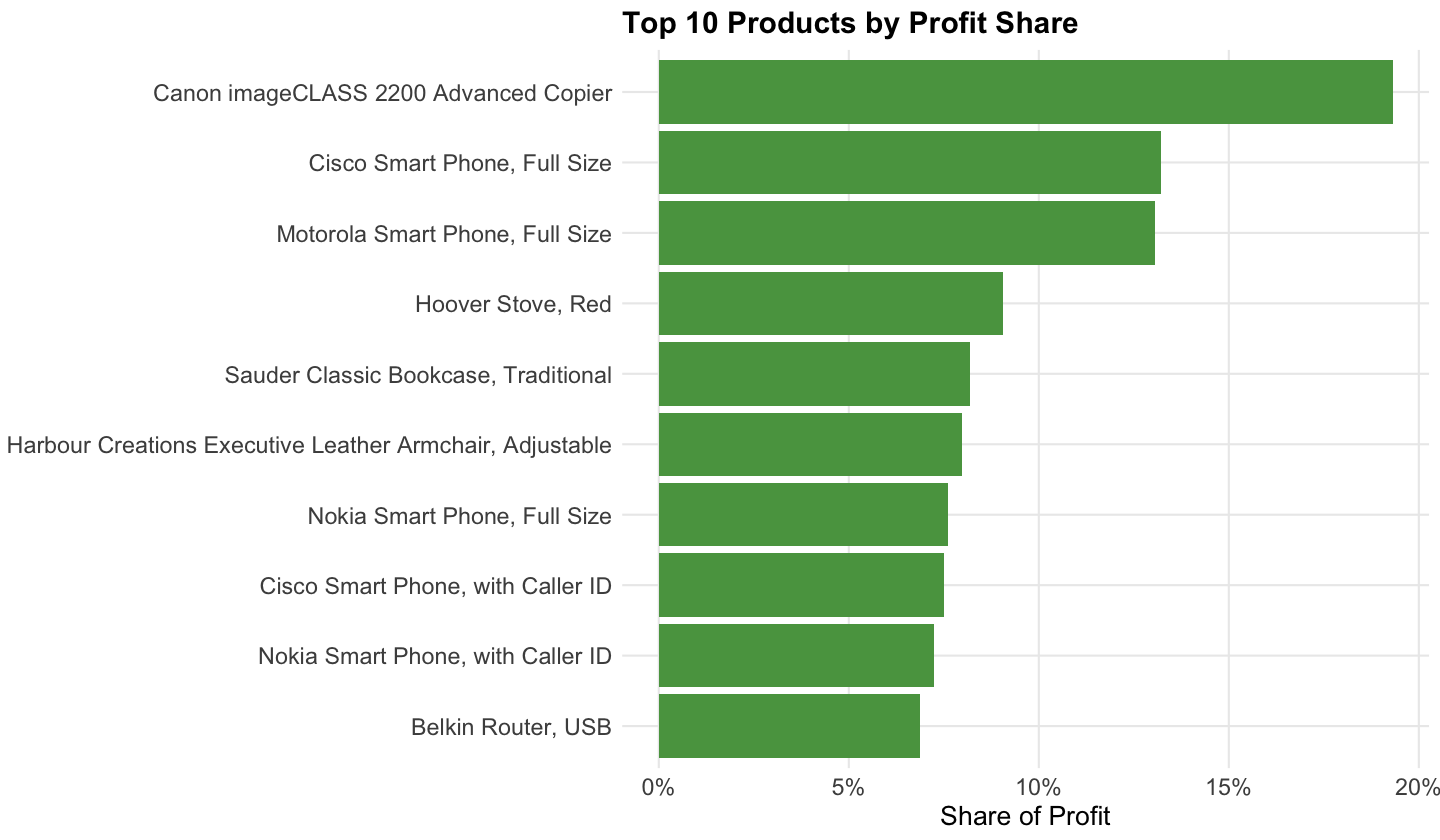

In [85]:
product_profit_share <- orders |> 
    group_by(product_name) |> 
    summarise(
        total_profit = sum(profit),
        .groups = "drop"
    ) |> 
    slice_max(total_profit, n = 10) |> 
    mutate(share = total_profit / sum(total_profit))

ggplot(
    product_profit_share,
    aes(x = reorder(product_name, share), y = share)
) +
    geom_col(fill = profit_color) +
    coord_flip() +
    scale_y_continuous(labels = scales::percent_format()) +
    labs(
        title = "Top 10 Products by Profit Share",
        x = NULL,
        y = "Share of Profit"
    ) 

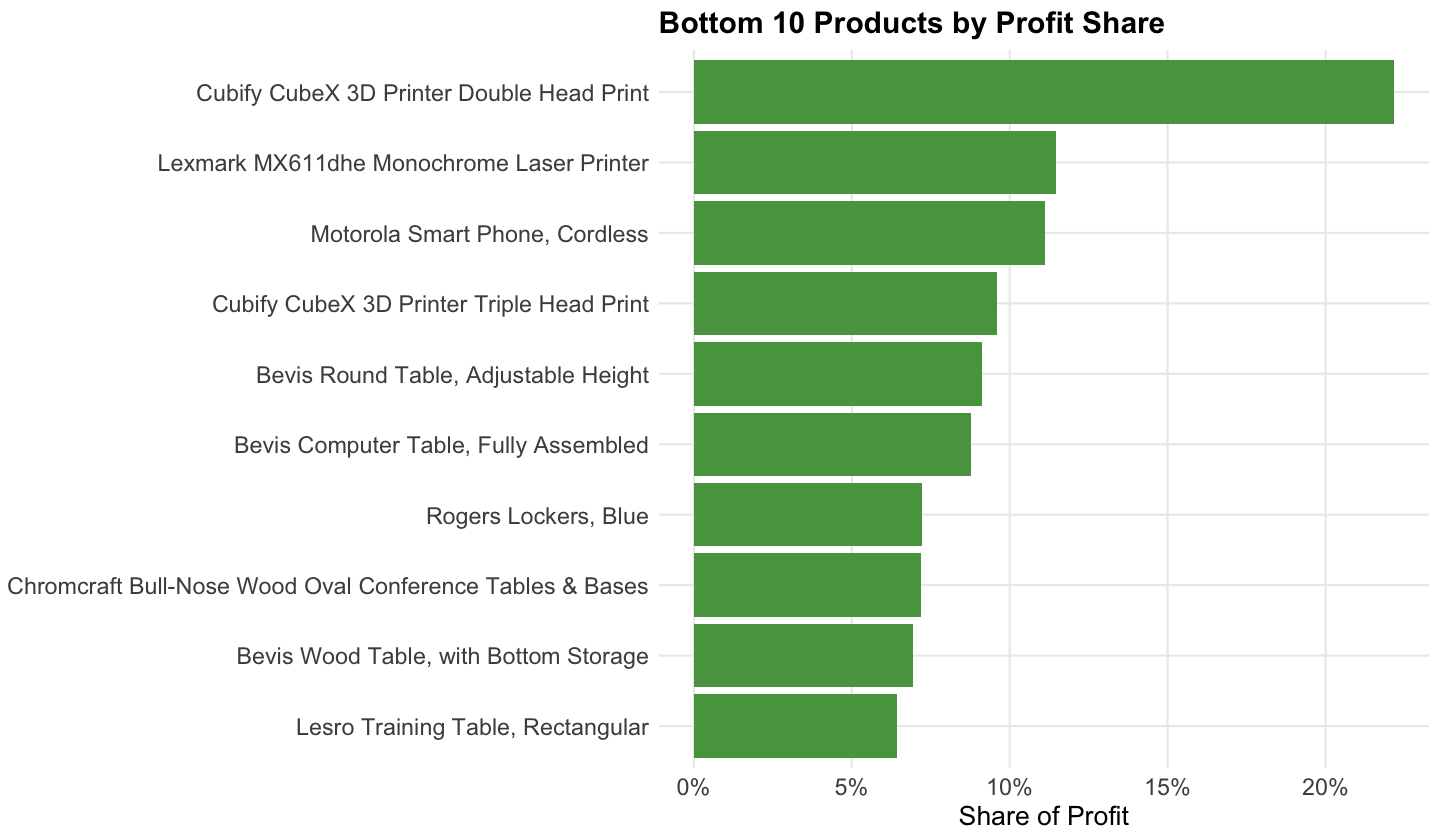

In [86]:
product_profit_share <- orders |> 
    group_by(product_name) |> 
    summarise(
        total_profit = sum(profit),
        .groups = "drop"
    ) |> 
    slice_min(total_profit, n = 10) |> 
    mutate(share = total_profit / sum(total_profit))

ggplot(
    product_profit_share,
    aes(x = reorder(product_name, share), y = share)
) +
    geom_col(fill = profit_color) +
    coord_flip() +
    scale_y_continuous(labels = scales::percent_format()) +
    labs(
        title = "Bottom 10 Products by Profit Share",
        x = NULL,
        y = "Share of Profit"
    )

### Profit margin by product

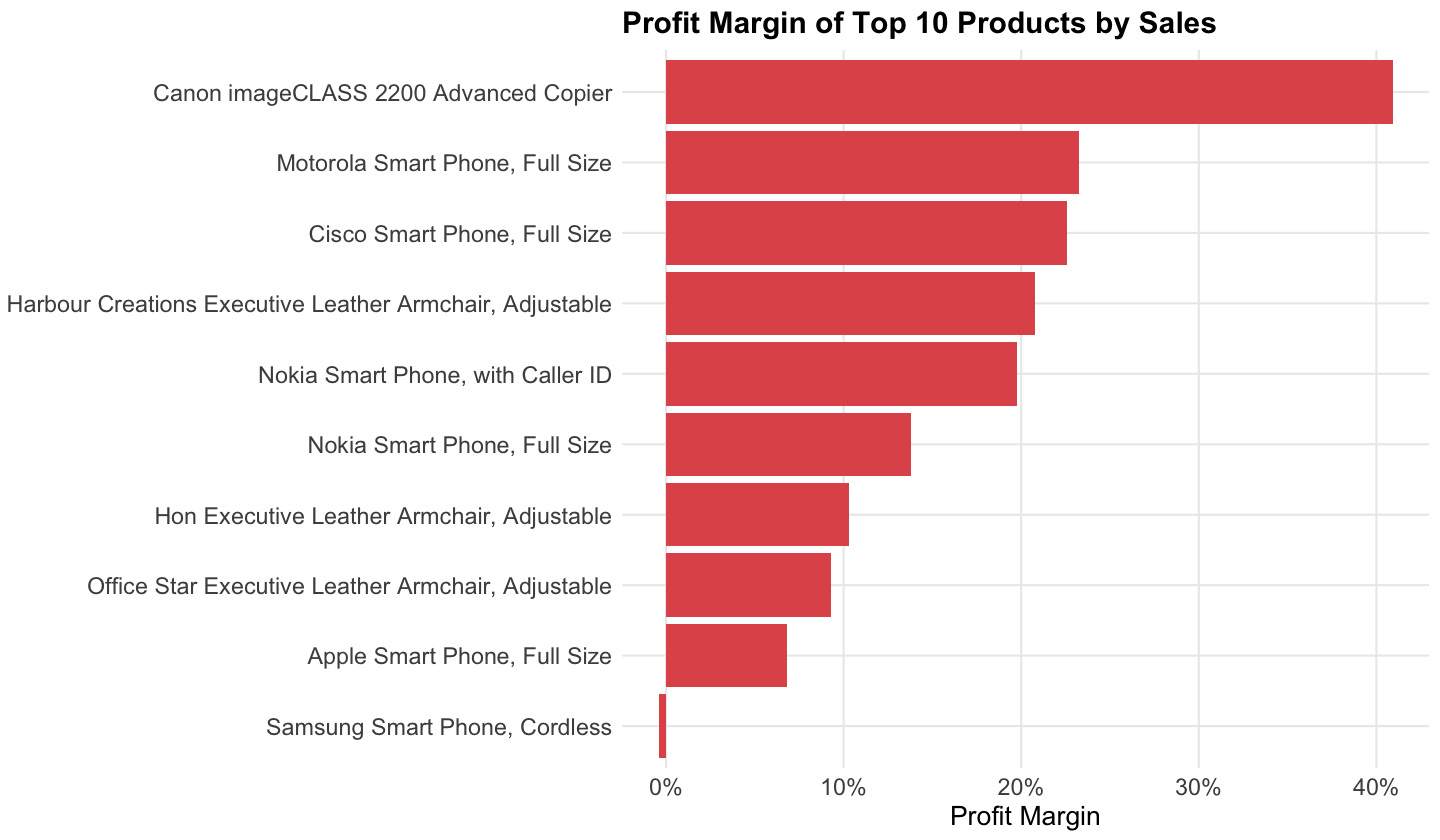

In [87]:
product_margin <- orders |> 
    group_by(product_name) |> 
    summarise(
        sales = sum(sales),
        profit = sum(profit),
        margin = profit / sales,
        .groups = "drop"
    ) |> 
    slice_max(sales, n = 10)

ggplot(
    product_margin,
    aes(x = reorder(product_name, margin), y = margin)
) +
    geom_col(fill = margin_color) +
    coord_flip() +
    scale_y_continuous(labels = scales::percent_format()) +
    labs(
        title = "Profit Margin of Top 10 Products by Sales",
        x = NULL,
        y = "Profit Margin"
    )

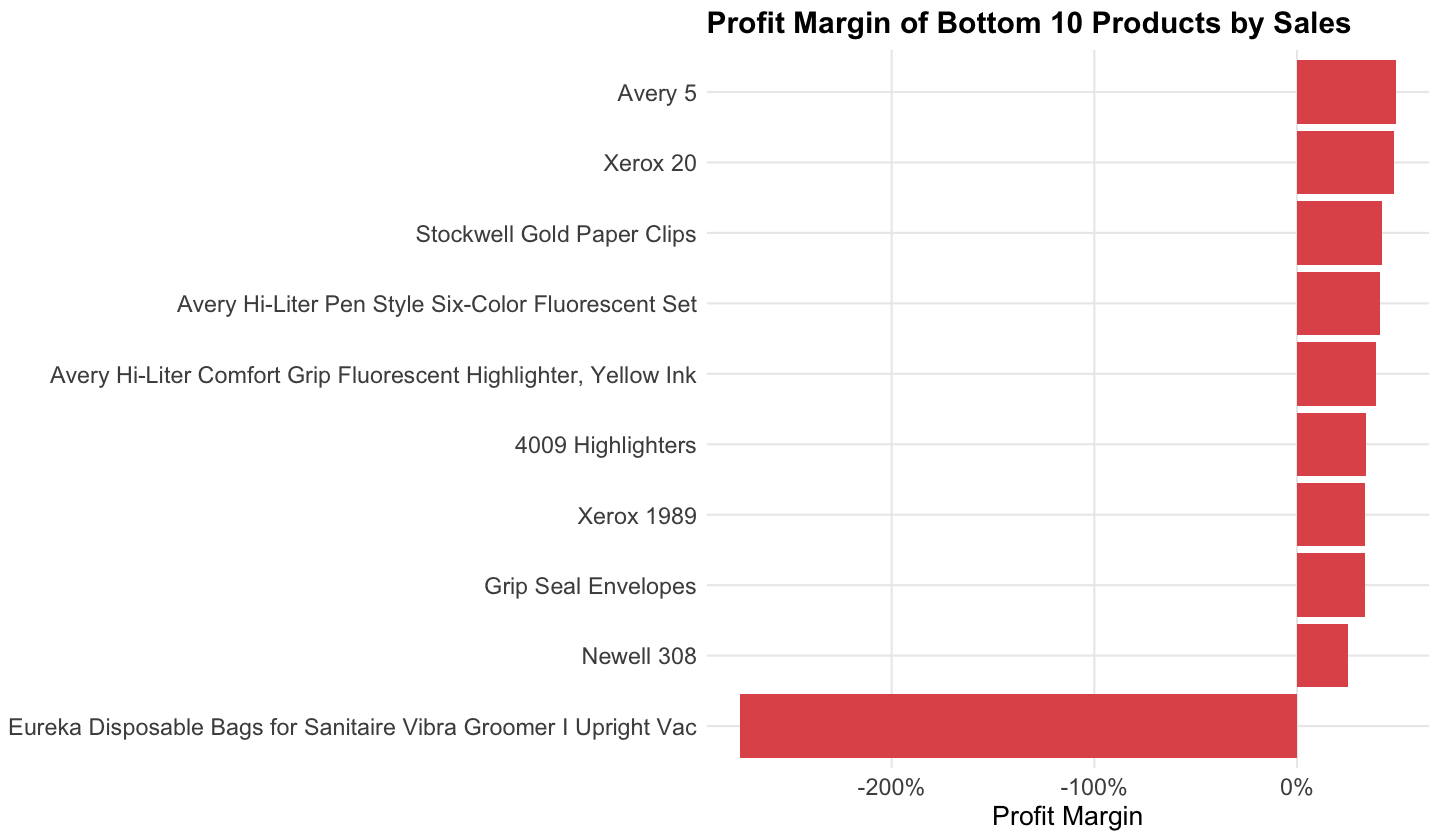

In [88]:
product_margin <- orders |> 
    group_by(product_name) |> 
    summarise(
        sales = sum(sales),
        profit = sum(profit),
        margin = profit / sales,
        .groups = "drop"
    ) |> 
    slice_min(sales, n = 10)

ggplot(
    product_margin,
    aes(x = reorder(product_name, margin), y = margin)
) +
    geom_col(fill = margin_color) +
    coord_flip() +
    scale_y_continuous(labels = scales::percent_format()) +
    labs(
        title = "Profit Margin of Bottom 10 Products by Sales",
        x = NULL,
        y = "Profit Margin"
    ) 

## Discount and Pricing Effects

### Discount vs Profit scatter

`geom_smooth()` using formula = 'y ~ x'


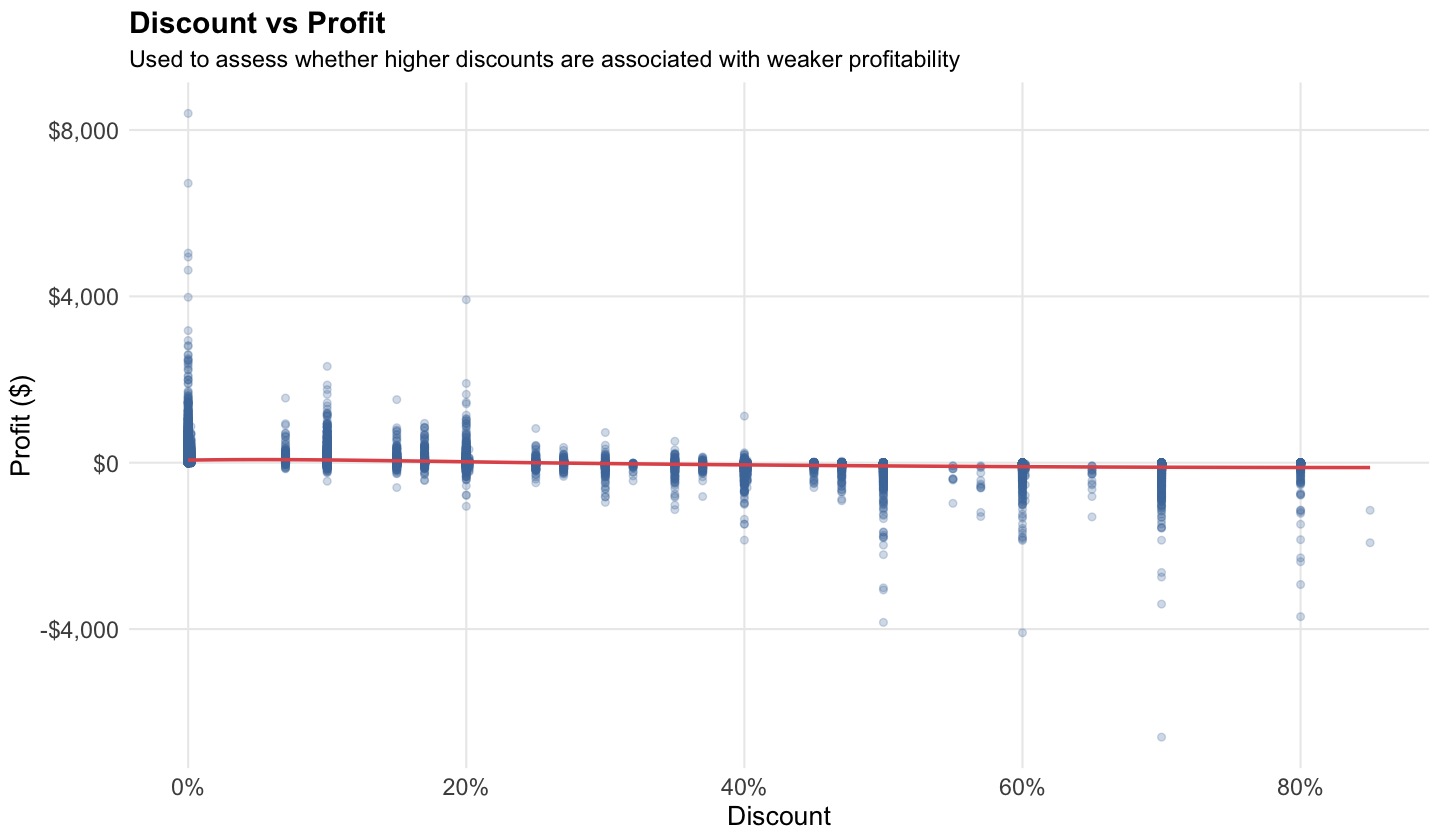

In [89]:
ggplot(orders, aes(x = discount, y = profit)) +
    geom_point(alpha = 0.25, color = sales_color) +
    geom_smooth(method = "loess", se = FALSE, color = margin_color, linewidth = 1) +
    scale_x_continuous(labels = scales::percent_format()) +
    scale_y_continuous(labels = scales::dollar_format()) +
    labs(
        title = "Discount vs Profit",
        subtitle = "Used to assess whether higher discounts are associated with weaker profitability",
        x = "Discount",
        y = "Profit ($)"
    )

### Average discount by category

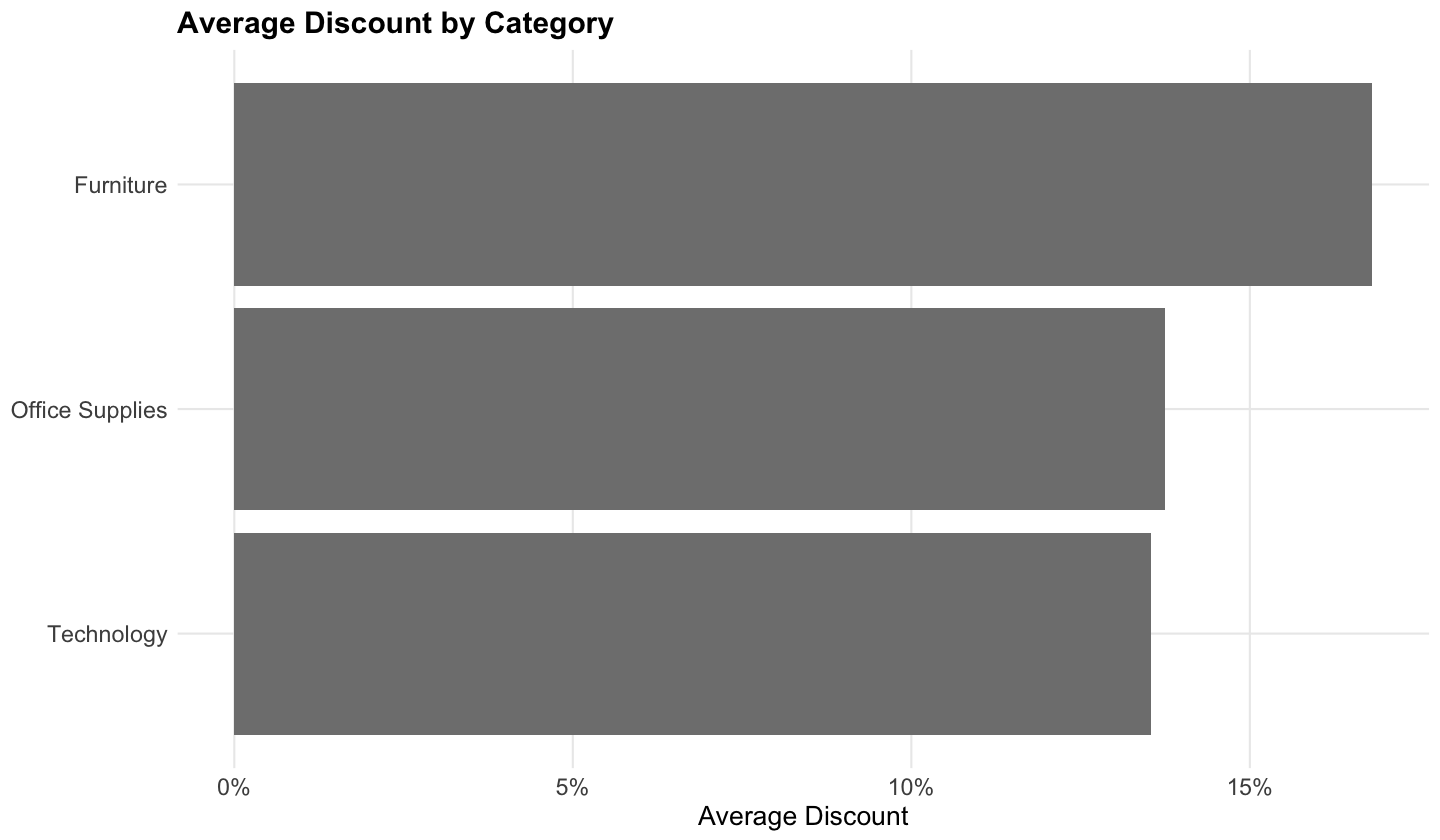

In [90]:
avg_discount_category <- orders |> 
    group_by(category) |> 
    summarise(
        avg_discount = mean(discount),
        .groups = "drop"
    )

ggplot(
    avg_discount_category,
    aes(x = reorder(category, avg_discount), y = avg_discount)
) +
    geom_col(fill = neutral_color) +
    coord_flip() +
    scale_y_continuous(labels = scales::percent_format()) +
    labs(
        title = "Average Discount by Category",
        x = NULL,
        y = "Average Discount"
    ) 

### Average discount by sub-category

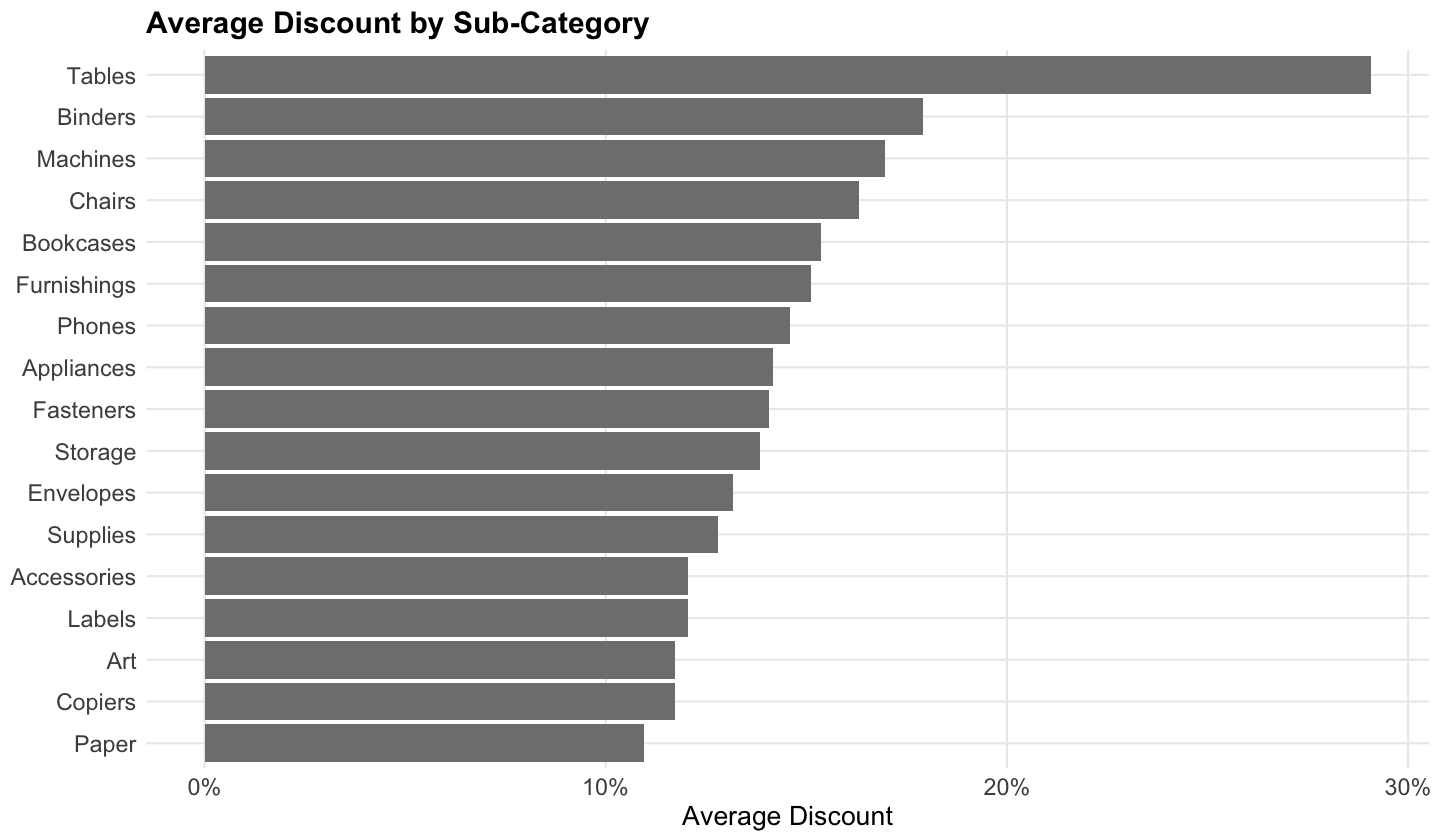

In [91]:
avg_discount_subcategory <- orders |> 
    group_by(sub_category) |> 
    summarise(
        avg_discount = mean(discount),
        .groups = "drop"
    )

ggplot(
    avg_discount_subcategory,
    aes(x = reorder(sub_category, avg_discount), y = avg_discount)
) +
    geom_col(fill = neutral_color) +
    coord_flip() +
    scale_y_continuous(labels = scales::percent_format()) +
    labs(
        title = "Average Discount by Sub-Category",
        x = NULL,
        y = "Average Discount"
    ) 

### Average discount by product

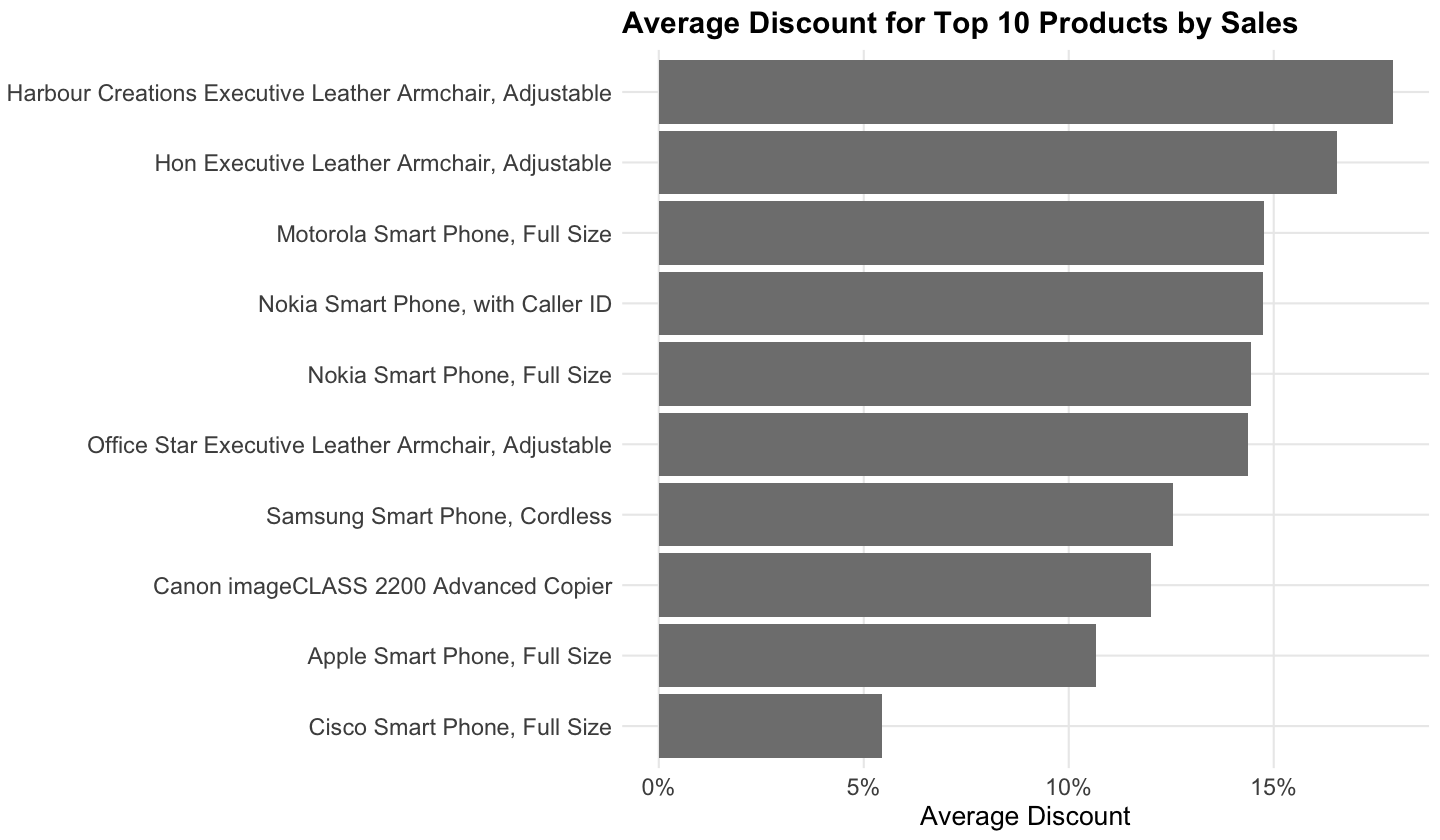

In [92]:
avg_discount_product <- orders |> 
    group_by(product_name) |> 
    summarise(
        avg_discount = mean(discount, na.rm = TRUE),
        total_sales = sum(sales),
        .groups = "drop"
    ) |> 
    slice_max(total_sales, n = 10)

ggplot(
    avg_discount_product,
    aes(x = reorder(product_name, avg_discount), y = avg_discount)
) +
    geom_col(fill = neutral_color) +
    coord_flip() +
    scale_y_continuous(labels = scales::percent_format()) +
    labs(
        title = "Average Discount for Top 10 Products by Sales",
        x = NULL,
        y = "Average Discount"
    ) 

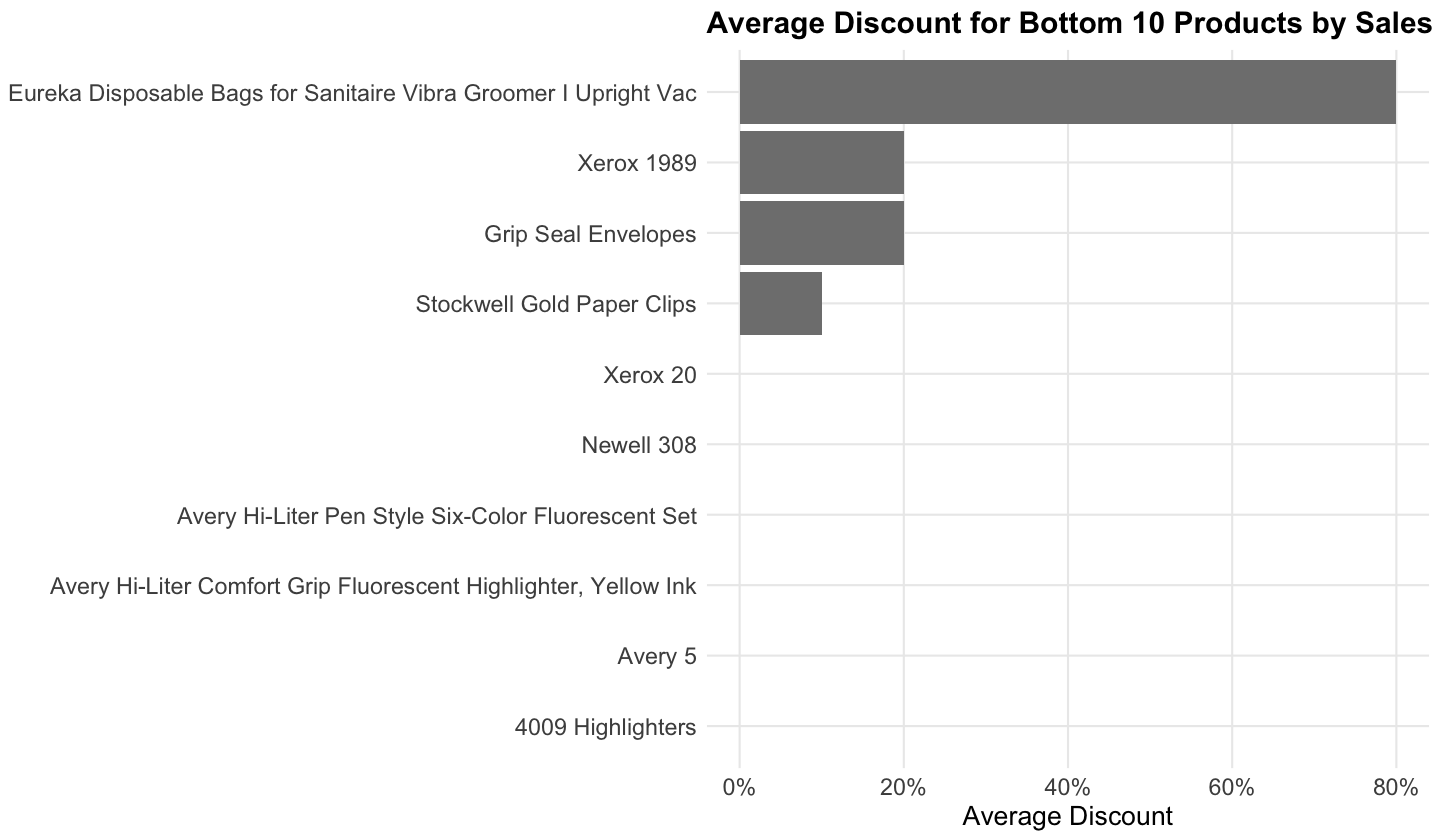

In [93]:
avg_discount_product <- orders |> 
    group_by(product_name) |> 
    summarise(
        avg_discount = mean(discount, na.rm = TRUE),
        total_sales = sum(sales),
        .groups = "drop"
    ) |> 
    slice_min(total_sales, n = 10)

ggplot(
    avg_discount_product,
    aes(x = reorder(product_name, avg_discount), y = avg_discount)
) +
    geom_col(fill = neutral_color) +
    coord_flip() +
    scale_y_continuous(labels = scales::percent_format()) +
    labs(
        title = "Average Discount for Bottom 10 Products by Sales",
        x = NULL,
        y = "Average Discount"
    ) 

### Section Interpretation

The discount visuals help assess whether pricing strategy is aligned with profitability. If higher discount levels are associated with lower profits, then discounting may be eroding value rather than supporting efficient sales growth. The category-, sub-category-, and product-level discount summaries are useful for identifying whether discounting behavior is concentrated in specific parts of the portfolio rather than distributed evenly across the business.

## Order Value and Concentration

### Distribution of order sales

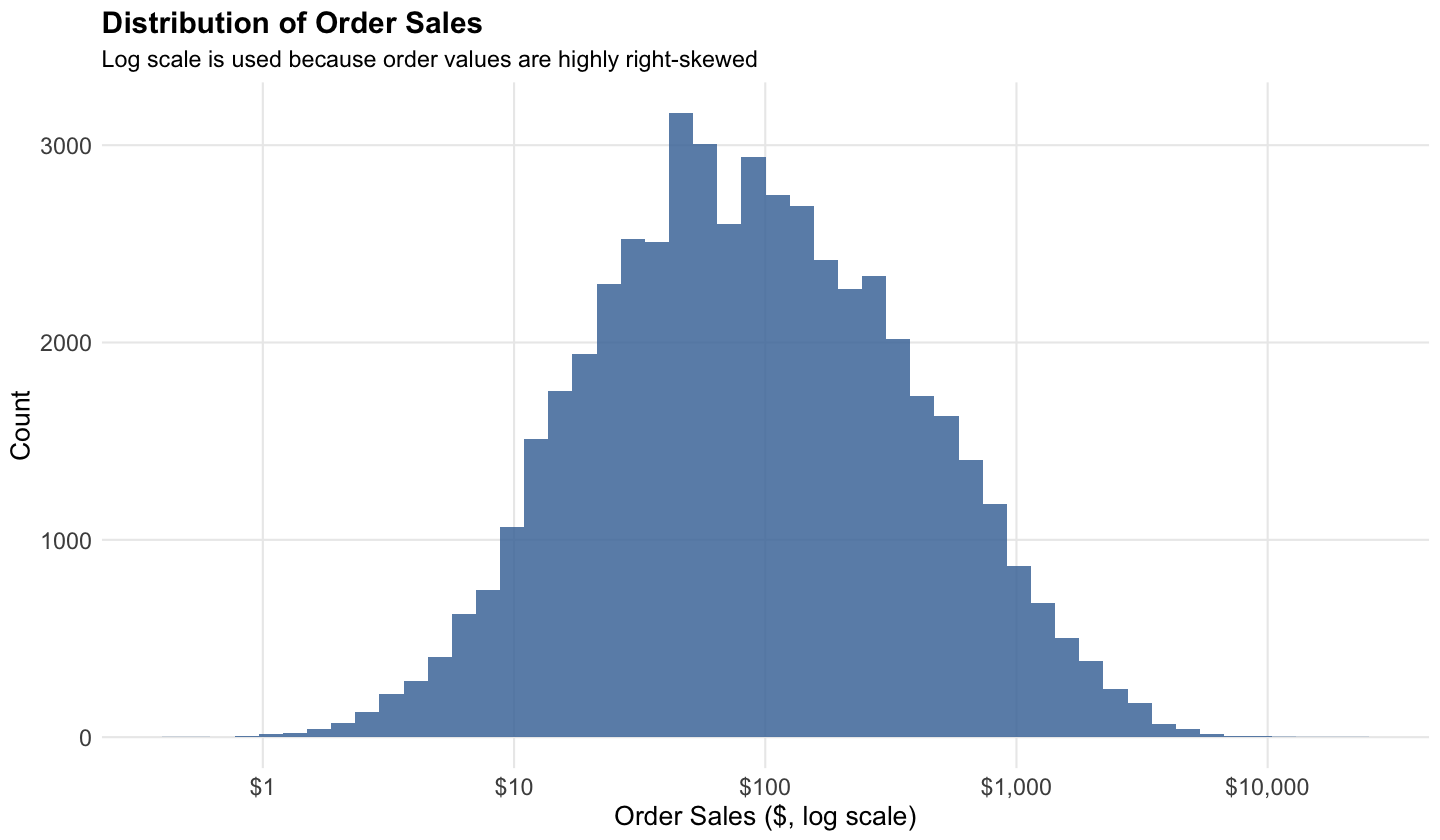

In [94]:
ggplot(orders, aes(x = sales)) +
    geom_histogram(bins = 50, fill = sales_color, alpha = 0.85) +
    scale_x_log10(labels = scales::dollar_format()) +
    labs(
        title = "Distribution of Order Sales",
        subtitle = "Log scale is used because order values are highly right-skewed",
        x = "Order Sales ($, log scale)",
        y = "Count"
    )

### Top X% of orders vs total sales contribution

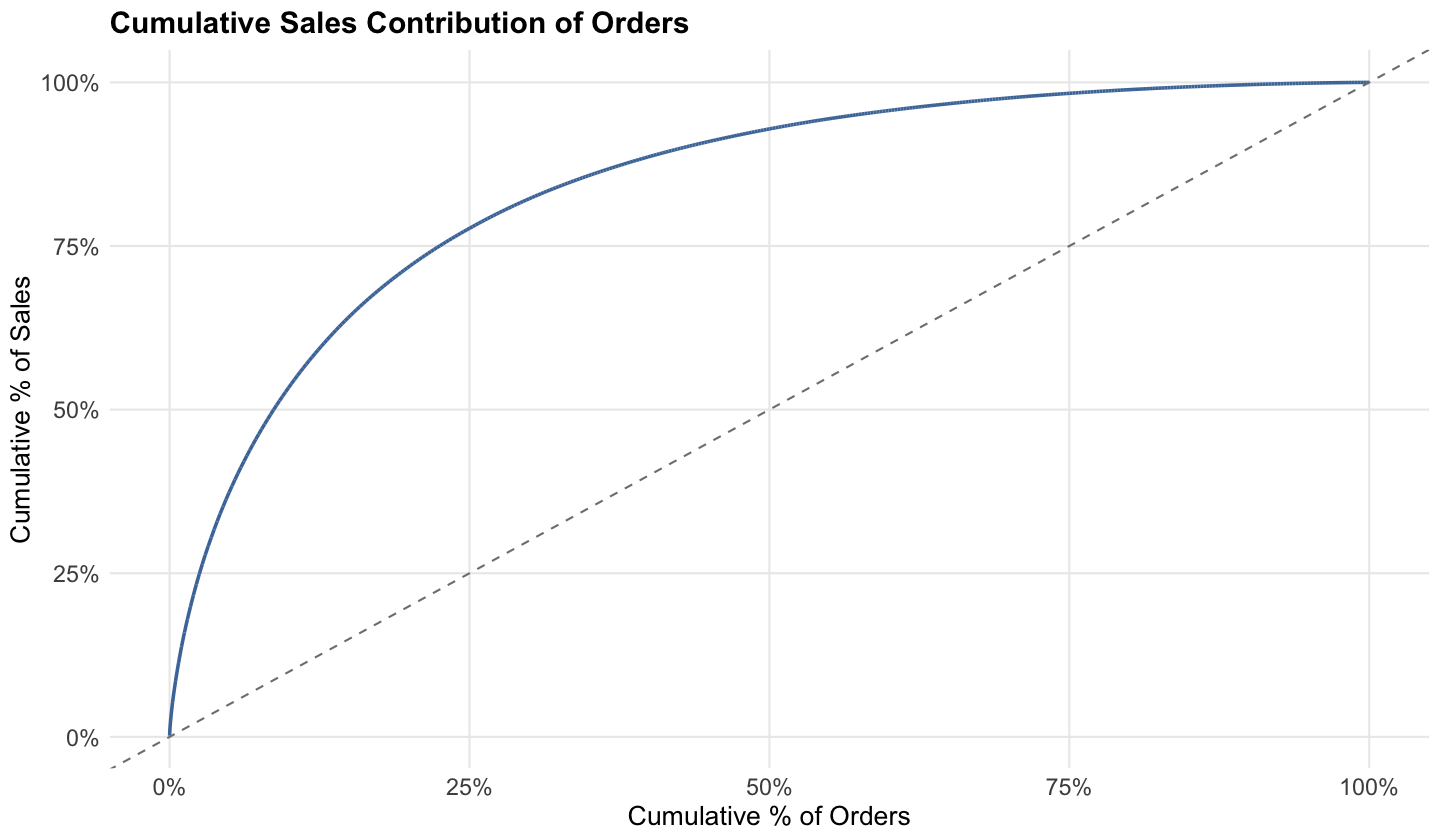

In [95]:
order_concentration <- orders |> 
    arrange(desc(sales)) |> 
    mutate(
        order_rank = row_number(),
        cum_orders = order_rank / n(),
        cum_sales  = cumsum(sales) / sum(sales)
    )

ggplot(
    order_concentration,
    aes(x = cum_orders, y = cum_sales)
) +
    geom_line(color = sales_color, linewidth = 1) +
    geom_abline(
        slope = 1, intercept = 0,
        linetype = "dashed", color = "grey50"
    ) +
    scale_x_continuous(labels = scales::percent_format()) +
    scale_y_continuous(labels = scales::percent_format()) +
    labs(
        title = "Cumulative Sales Contribution of Orders",
        x = "Cumulative % of Orders",
        y = "Cumulative % of Sales"
    ) 

### Top X% of products vs total sales contribution

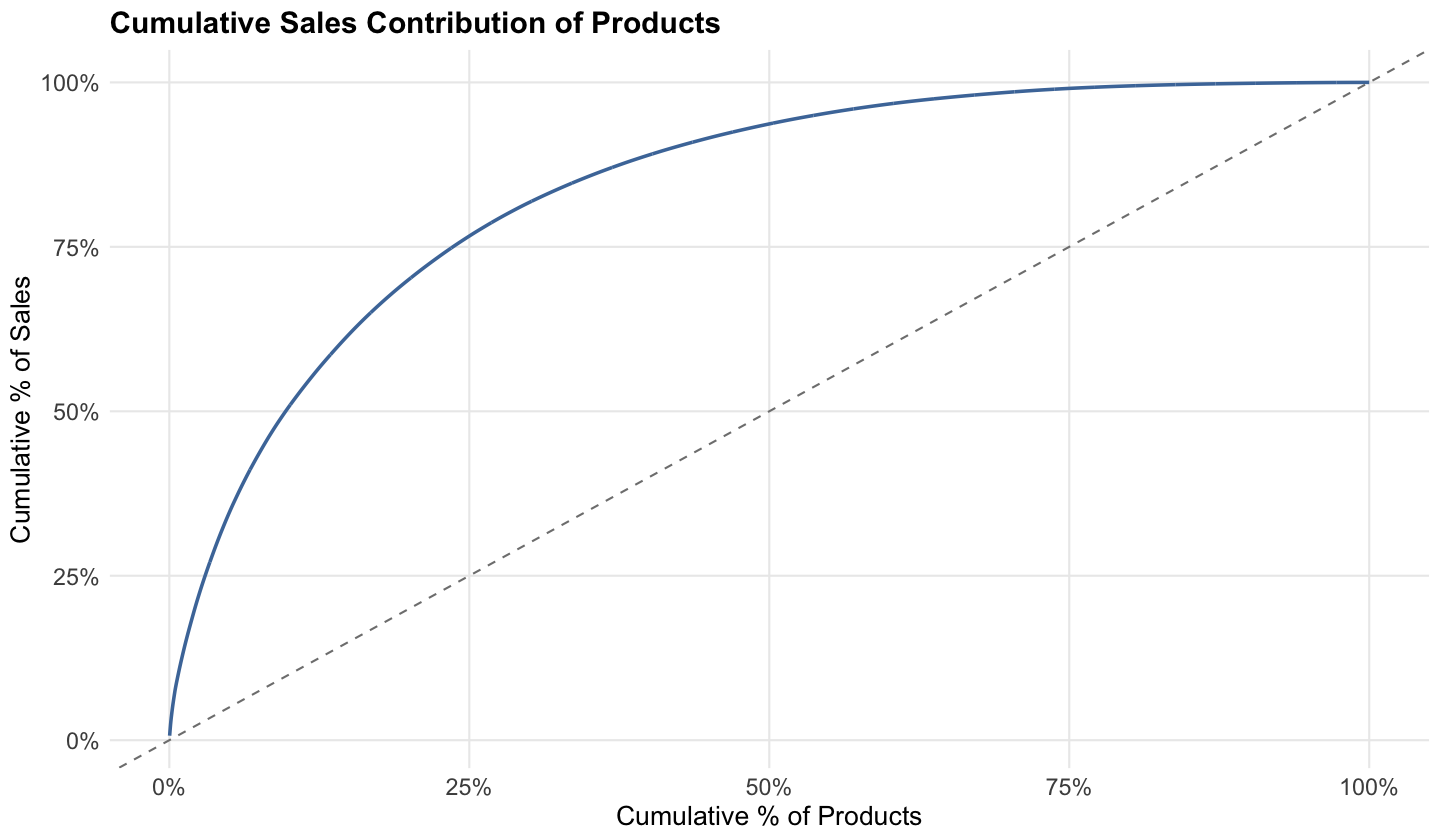

In [96]:
product_sales <- orders |> 
    group_by(product_name) |> 
    summarise(
        total_sales = sum(sales),
        .groups = "drop"
    )

product_concentration <- product_sales |> 
    arrange(desc(total_sales)) |> 
    mutate(
        product_rank = row_number(),
        cum_products = product_rank / n(),
        cum_sales = cumsum(total_sales) / sum(total_sales)
    )

ggplot(product_concentration, aes(x = cum_products, y = cum_sales)) +
    geom_line(color = sales_color, linewidth = 1) +
    geom_abline(slope = 1, intercept = 0, linetype = "dashed", color = "grey50") +
    scale_x_continuous(labels = scales::percent_format()) +
    scale_y_continuous(labels = scales::percent_format()) +
    labs(
        title = "Cumulative Sales Contribution of Products",
        x = "Cumulative % of Products",
        y = "Cumulative % of Sales"
    ) 

### Section Interpretation

The concentration plots show whether sales are broadly distributed across orders and products or dominated by a relatively small share of them. A steep cumulative curve indicates concentration, meaning that a limited subset of orders or products contributes a disproportionately large share of total sales. This is important because concentrated sales structures can increase business risk and make performance more dependent on a small part of the portfolio.